[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/07_industry_applications/A11_routing_allocation.ipynb)

> 📎 **Appendix notebook — full-lesson style.** Module 7's eleventh appendix (see `README.md`), written like the module's core notebooks: same rhythm, same ✋/🧪/🧠 ladder. It runs on the core course stack (`numpy`, `pandas`, `scipy`, `scikit-learn`, `matplotlib`, `seaborn`) with all data generated inline — 100 % offline.

---
# 📓 Notebook A11 (IA) — From Prediction to Allocation: Routing, Dispatch & Slack

> **Module:** Industry Applications · **Type:** Appendix · **Estimated time:** ~2 h 45 m · **Difficulty:** ⭐⭐ (stretch ⭐⭐⭐)

Every notebook in this module so far ends in the same shape of object: a **threshold** or a **ranked list**. NB 23 ranks customers by expected value and cuts at break-even. NB 24 sizes an alert queue to analyst capacity. A6 ranks invoices by cash acceleration, A7 ranks leads by expected pipeline, A8 ranks suppliers by total cost. In every case the deliverable is *an ordering plus a line drawn across it*, and the model's job is to produce the score that does the ordering.

This notebook ends in something else: **a plan under constraints**. The webshop you have been analysing since NB 25 also installs and repairs the IT equipment it sells — six technicians, roughly **40 jobs a day** across the metro area, and a promise printed on every confirmation email: *we will arrive inside a two-hour window*. The dispatcher builds tomorrow's schedule every evening in a spreadsheet. There is no threshold to tune here. There is no list to cut. There is an **assignment** (which technician), a **sequence** (in what order), and a **timetable** (promised at what time) — and the moment you write those three things down you have made forty commitments that interact with each other.

The module's first lesson was *a probability is not a decision*. This notebook adds the sequel: **a prediction is not an allocation either.** Between them sit an objective, a set of constraints, and — the part that separates schedules that work from schedules that look good — a tolerance for the day going wrong.

> 🧠 **Mental model.** A plan is a **portfolio of promises**, and like any portfolio it has an expected value and a variance. §3 shows what happens when you optimise the expected value of the wrong quantity (kilometres). §4 optimises the right one (euros). §5 is where the notebook earns its place: the euro-optimal plan is the *tightest* plan, and the tightest plan is the most fragile — it is priced as if Tuesday will behave. Slack is what you buy so it doesn't have to. That makes slack **insurance**, and you should recognise the shape: it is A3 §5's credit limits and A8 §5's dual sourcing, wearing a van.

## 🎯 Learning objectives

By the end you can:

1. State a field-service day as an **optimisation problem** — objective in euros, constraints from skills, shifts and customer promises — and explain why *"minimise total distance"* is almost never that objective.
2. Fit a **travel-time model**, beat two named baselines with it, and then make the point that matters more than its MAE: for a *schedule*, the **error distribution** beats the mean, because errors **accumulate along a route**.
3. Build the two layers of a routing solution on the course stack: **`scipy.optimize.linear_sum_assignment`** for jobs → technician, and **greedy insertion + 2-opt** for the sequence inside a route.
4. Price three plans — distance-optimal, euro-optimal, and the dispatcher's manual plan — on kilometres, windows hit, overtime and **total euros per day**.
5. **Monte-Carlo a schedule** against the measured travel-time and service-time error distributions, show how one early delay cascades, and choose a **slack** level from euros rather than from feeling.
6. Say what a production routing system adds — and why *a better schedule the dispatcher refuses to run is worth nothing*.

## ✅ Prerequisites

**NB 25** (the B2B webshop whose service arm this is), **NB 26** (safety stock — §5 is the same *buffer against variance* argument in the time domain), **NB 24** (capacity-constrained queues), and **A3 §5** / **A8 §5** (risk priced as insurance — §5 is their third appearance). **NB 10** for reading a simulated distribution. `scipy.optimize` ships with the course stack; everything else is generated inline and runs offline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

# ---- the price list the dispatcher is actually optimising against (EUR) ----
KM_COST = 0.42            # van running cost per km (fuel, tyres, wear)
WINDOW_CREDIT = 35.0      # contractual credit when we miss a 2-hour window
REVISIT_COST = 85.0       # the job still has to be done: a second trip tomorrow
REPUTATION_TAIL = 30.0    # finance's estimate of the complaint/churn tail
MISS_COST = WINDOW_CREDIT + REVISIT_COST + REPUTATION_TAIL     # 150.00
DEFER_COST = 60.0         # phoning the customer the evening before and rebooking
OT_MIN = 48.0 / 60.0      # overtime, EUR per minute (EUR 48/hour)
SHIFT_START, SHIFT_END = 8 * 60, 16 * 60      # minutes past midnight
CIRCUITY = 1.25           # roads are longer than straight lines

print(f"Missing a window costs EUR {MISS_COST:.0f} "
      f"({WINDOW_CREDIT:.0f} credit + {REVISIT_COST:.0f} revisit + {REPUTATION_TAIL:.0f} reputation); "
      f"rebooking it the night before costs EUR {DEFER_COST:.0f}.")
print(f"Overtime EUR {OT_MIN * 60:.0f}/h | driving EUR {KM_COST:.2f}/km | shift 08:00-16:00.")

Missing a window costs EUR 150 (35 credit + 85 revisit + 30 reputation); rebooking it the night before costs EUR 60.
Overtime EUR 48/h | driving EUR 0.42/km | shift 08:00-16:00.


## 1. The business: 40 jobs, 6 vans, one promise

The webshop's **field-service arm** installs and repairs what the shop sells: switches and access points (`network`), desktops and docking stations (`workstation`), and the printer estate nobody enjoys (`printer`). Six technicians work out of one depot, each with their own skill set and their own usual patch of the city. Tomorrow's board has **40 jobs**.

Three things make this harder than it sounds:

- **The promise.** Every customer was given a **two-hour arrival window**. Miss it and the contract pays a €35 credit — but the real bill is bigger, because the job still has to be done (a second van-trip, €85) and the complaint has a tail (€30). We will treat a missed window as **€150** throughout, and we will treat *rebooking a job the evening before* — an agreed reschedule, no credit, no complaint — as **€60**. Those two numbers are the entire moral universe of this notebook.
- **The skills.** Not every technician can do every job. This is a hard constraint, not a preference.
- **The clock.** Six vans × eight hours is **48 hours** of capacity. The 40 jobs need **24.3 hours** of on-site work. That sounds like plenty of room until you notice the other half of the day is spent driving.

Everything below is generated inline from seeded RNGs: tomorrow's job board, one year of the fleet's own **trip records** (which is what §2's travel-time model learns from), and the workshop's **job-duration log** (which §5 needs).

In [2]:
DEPOT = (15.0, 15.0)                       # the yard, in a 30 x 30 km metro grid
PATCHES = np.array([[8., 10.], [21., 9.], [13., 21.], [24., 20.], [16., 14.]])
PATCH_W = [.22, .20, .20, .18, .20]        # where the customers actually are

TECHS = pd.DataFrame([
    ("Aylin",  "network,workstation",          8.5, 10.5),
    ("Bendix", "workstation,printer",         21.0,  9.0),
    ("Cem",    "network",                     13.0, 21.0),
    ("Doro",   "workstation",                 24.0, 20.0),
    ("Elias",  "network,workstation,printer", 16.0, 14.0),
    ("Freya",  "workstation,printer",         11.5, 16.0),
], columns=["tech", "skills", "home_x", "home_y"])
TECHS["skills"] = TECHS.skills.str.split(",").apply(set)


def sample_points(rng, n):
    k = rng.choice(len(PATCHES), n, p=PATCH_W)
    return (PATCHES[k] + rng.normal(0, 2.2, (n, 2))).clip(1, 29)


def build_jobs(seed=7, n=40):
    """Tomorrow's board: where, how long, what skill, which 2-hour window."""
    rng = np.random.default_rng(seed)
    xy = sample_points(rng, n)
    ws = rng.choice([8, 9, 10, 11, 12, 13, 14], n, p=[.17, .16, .15, .14, .13, .13, .12])
    return pd.DataFrame(dict(
        job=[f"J{i:02d}" for i in range(1, n + 1)],
        x=xy[:, 0].round(2), y=xy[:, 1].round(2),
        service_min=rng.choice([20, 30, 45, 60], n, p=[.25, .30, .28, .17]),
        skill=rng.choice(["network", "workstation", "printer"], n, p=[.34, .46, .20]),
        sla=rng.choice(["standard", "business", "premium"], n, p=[.45, .35, .20]),
        win_start=ws * 60, win_end=(ws + 2) * 60))


jobs = build_jobs()
N = len(jobs)
print(jobs.head(6).to_string(index=False))
print(f"\n{N} jobs | {jobs.service_min.sum()} minutes of on-site work "
      f"({jobs.service_min.sum() / 60:.1f} h) against {len(TECHS) * 8} h of fleet time")
print("skills:", jobs.skill.value_counts().to_dict(), "| SLA:", jobs.sla.value_counts().to_dict())

job     x     y  service_min       skill      sla  win_start  win_end
J01 23.75 20.24           20     printer standard        480      600
J02 16.14 11.30           60 workstation standard        720      840
J03 24.17 22.99           60 workstation business        780      900
J04 17.60 10.89           20     network business        660      780
J05 21.26  7.59           45 workstation standard        720      840
J06 20.40 15.68           30     network standard        540      660

40 jobs | 1460 minutes of on-site work (24.3 h) against 48 h of fleet time
skills: {'workstation': 15, 'network': 14, 'printer': 11} | SLA: {'standard': 23, 'business': 12, 'premium': 5}


In [3]:
def speed_kmh(hour, weekday):
    """Average city speed. Two rush peaks; Fridays are worse all day."""
    hour, weekday = np.asarray(hour, float), np.asarray(weekday, float)
    rush = (18.0 * np.exp(-0.5 * ((hour - 8.0) / 1.2) ** 2)
            + 17.0 * np.exp(-0.5 * ((hour - 16.5) / 1.5) ** 2))
    return 36.0 - rush - 2.5 * (weekday == 4)


def build_trips(seed=11, n=12_000):
    """One year of the fleet's own trip records: 12,000 legs actually driven."""
    rng = np.random.default_rng(seed)
    o, d = sample_points(rng, n), sample_points(rng, n)
    dist = CIRCUITY * np.hypot(*(o - d).T)
    day = rng.integers(0, 250, n)
    dep = rng.uniform(7.0, 18.0, n)
    free = 4.0 + 60 * dist / speed_kmh(dep, day % 5)      # +4 min to park and find the door
    jam = rng.lognormal(-0.5 * 0.26 ** 2, 0.26, n)        # ordinary traffic noise (right-skewed)
    incident = np.where(rng.random(n) < 0.06, 1 + rng.exponential(0.8, n), 1.0)   # the tail
    return pd.DataFrame(dict(day=day, weekday=day % 5, dep_hour=dep.round(2),
                             dist_km=dist.round(2),
                             travel_min=(free * jam * incident).round(1))
                        ).sort_values("day", kind="stable").reset_index(drop=True)


def build_service_log(seed=13, n=4_000):
    """The workshop's own log: how long jobs were estimated to take, and how long they took."""
    rng = np.random.default_rng(seed)
    est = rng.choice([20, 30, 45, 60], n, p=[.25, .30, .28, .17])
    spread = rng.lognormal(-0.5 * 0.20 ** 2, 0.20, n)
    overrun = 1 + (rng.random(n) < 0.15) * rng.exponential(0.45, n)   # 'the cable was in a wall'
    return pd.DataFrame(dict(
        skill=rng.choice(["network", "workstation", "printer"], n, p=[.34, .46, .20]),
        est_min=est, actual_min=(est * spread * overrun / (1 + 0.15 * 0.45)).round(1)))


trips = build_trips()
slog = build_service_log()
ratio_s = slog.actual_min / slog.est_min
print(f"trip log     : {len(trips):,} legs | median {trips.travel_min.median():.1f} min | "
      f"mean {trips.travel_min.mean():.1f} | 95th pct {trips.travel_min.quantile(.95):.1f}")
print(f"duration log : {len(slog):,} jobs | actual/estimated: median {ratio_s.median():.2f}, "
      f"mean {ratio_s.mean():.2f}, 90th pct {ratio_s.quantile(.9):.2f} | "
      f"{(slog.actual_min - slog.est_min > 15).mean():.0%} over-run by more than 15 minutes")

trip log     : 12,000 legs | median 31.9 min | mean 36.8 | 95th pct 80.3
duration log : 4,000 jobs | actual/estimated: median 0.94, mean 1.00, 90th pct 1.31 | 7% over-run by more than 15 minutes


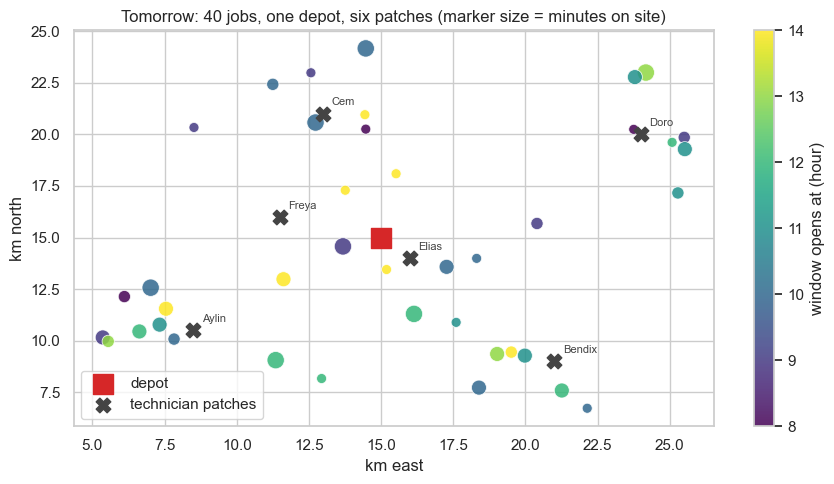

In [4]:
# node 0 = depot, 1..40 = jobs, 41..46 = the technicians' home addresses (Stretch A uses those)
pts = np.vstack([DEPOT, jobs[["x", "y"]].to_numpy(), TECHS[["home_x", "home_y"]].to_numpy()])
DIST = CIRCUITY * np.hypot(pts[:, None, 0] - pts[None, :, 0], pts[:, None, 1] - pts[None, :, 1])
SERVICE = np.r_[0.0, jobs.service_min.to_numpy(), np.zeros(len(TECHS))]
WOPEN = np.r_[0.0, jobs.win_start.to_numpy(), np.zeros(len(TECHS))]
WCLOSE = np.r_[1e9, jobs.win_end.to_numpy(), np.full(len(TECHS), 1e9)]
SKILL = ["depot"] + jobs.skill.tolist() + ["home"] * len(TECHS)
NAME = ["DEPOT"] + jobs.job.tolist() + TECHS.tech.tolist()
HOME = {r.tech: N + 1 + i for i, r in enumerate(TECHS.itertuples())}

# FIG 1 -- tomorrow, on a map
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(jobs.x, jobs.y, c=jobs.win_start / 60, s=jobs.service_min * 2.6,
                cmap="viridis", alpha=0.85, edgecolor="white", linewidth=0.6)
ax.scatter(*DEPOT, marker="s", s=200, color="#d62728", zorder=5, label="depot")
ax.scatter(TECHS.home_x, TECHS.home_y, marker="X", s=110, color="#444444",
           zorder=4, label="technician patches")
for r in TECHS.itertuples():
    ax.annotate(r.tech, (r.home_x, r.home_y), textcoords="offset points",
                xytext=(6, 6), fontsize=8, color="#444444")
plt.colorbar(sc, ax=ax, label="window opens at (hour)")
ax.set_xlabel("km east"); ax.set_ylabel("km north")
ax.set_title("Tomorrow: 40 jobs, one depot, six patches (marker size = minutes on site)")
ax.legend(loc="lower left")
plt.tight_layout()

Read the map the way the dispatcher does. The jobs sit in five loose neighbourhoods; the depot is central; the technicians have patches, but the patches overlap and the **colour is the problem**. Geography says *"do the north-east cluster together"*; the colours say *"but that one is a 08:00–10:00 promise and its neighbour is 14:00–16:00"*. A schedule has to satisfy both at once, and the two are not correlated.

Now the arithmetic that decides how hard tomorrow is. **24.3 hours** of on-site work against **48 hours** of fleet time looks like 50 % utilisation — until you add driving. §2 will estimate the fleet's legs at roughly 20–25 minutes each, and 46 legs of that is another **~16 hours**. That puts the day at roughly **85 % utilisation**, which is exactly the regime where a schedule can be perfect on paper and unrecognisable by 11:00.

## 2. Predict travel time — and notice which part matters

The dispatcher's spreadsheet assumes 30 km/h. The fleet has 12,000 of its own trips, so let's do better: a small model on **distance × departure hour × weekday**, trained on the first 200 days and tested on the last 50 (respect time, as always — a travel-time model fitted on shuffled days is fitted on tomorrow's traffic).

We will judge it against two named baselines: the honest dumb one (**"about 35 minutes"** — the mean of the training set) and the dispatcher's actual rule (**30 km/h plus 4 minutes to park**).

In [5]:
train, test = trips[trips.day < 200], trips[trips.day >= 200]
FEAT = ["dist_km", "dep_hour", "weekday"]

tt_model = HistGradientBoostingRegressor(random_state=0).fit(train[FEAT], train.travel_min)
pred = tt_model.predict(test[FEAT])

for label, p in [("flat 'about 35 minutes'", np.full(len(test), train.travel_min.mean())),
                 ("the 30 km/h + 4 min rule", 4.0 + 60 * test.dist_km / 30.0),
                 ("model (dist x hour x weekday)", pred)]:
    print(f"{label:32s} MAE {mean_absolute_error(test.travel_min, p):5.2f} min")
print(f"\ntest legs: {len(test):,} (days 200-249, never seen in training)")

flat 'about 35 minutes'          MAE 17.59 min
the 30 km/h + 4 min rule         MAE 11.35 min
model (dist x hour x weekday)    MAE  9.20 min

test legs: 2,353 (days 200-249, never seen in training)


**9.20 minutes** against the rule of thumb's 11.35 — a 19 % improvement, worth having, and completely beside the point.

Here is the pivot that justifies this whole notebook. A travel-time model is usually evaluated as if its job were to be right *on average*. For a schedule it is not. A schedule is a chain: the arrival at stop 4 is the departure from stop 3 plus a leg, and stop 3's departure already contains everything that went wrong at stops 1 and 2. **Errors do not cancel along a route — they accumulate.** And the thing being accumulated is *not symmetric*: traffic delays are right-skewed. A leg can run 200 % long; it cannot run 200 % short.

So the object we actually need from §2 is not the MAE. It is the **distribution of realised ÷ predicted**, measured on held-out legs.

mean 1.010   median 0.947   75th 1.16   90th 1.39   99th 2.25
42.5% of legs run LONGER than predicted -- the mean is unbiased, the median is not the mean


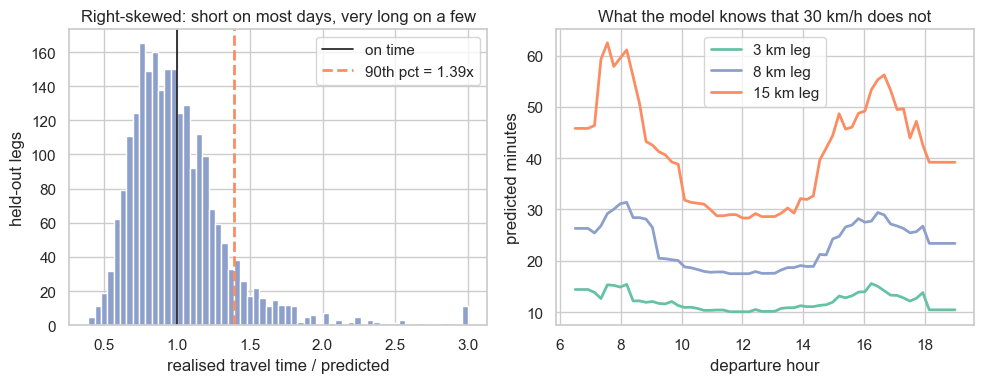

In [6]:
err = test.travel_min.to_numpy() / np.maximum(pred, 1.0)      # realised / predicted, held out
print(f"mean {err.mean():.3f}   median {np.median(err):.3f}   "
      f"75th {np.quantile(err, .75):.2f}   90th {np.quantile(err, .90):.2f}   "
      f"99th {np.quantile(err, .99):.2f}")
print(f"{(err > 1).mean():.1%} of legs run LONGER than predicted "
      f"-- the mean is unbiased, the median is not the mean")

# FIG 2 -- the error distribution, and where the systematic part lives
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(np.clip(err, 0, 3), bins=60, color="#8da0cb", edgecolor="white")
axes[0].axvline(1.0, color="k", lw=1.2, label="on time")
axes[0].axvline(np.quantile(err, .90), color="#fc8d62", ls="--", lw=2,
                label=f"90th pct = {np.quantile(err, .90):.2f}x")
axes[0].set_xlabel("realised travel time / predicted"); axes[0].set_ylabel("held-out legs")
axes[0].set_title("Right-skewed: short on most days, very long on a few")
axes[0].legend()

hours = np.linspace(6.5, 19, 60)
for km, colour in [(3.0, "#66c2a5"), (8.0, "#8da0cb"), (15.0, "#fc8d62")]:
    g = pd.DataFrame({"dist_km": km, "dep_hour": hours, "weekday": 1.0})
    axes[1].plot(hours, tt_model.predict(g[FEAT]), lw=2, color=colour, label=f"{km:.0f} km leg")
axes[1].set_xlabel("departure hour"); axes[1].set_ylabel("predicted minutes")
axes[1].set_title("What the model knows that 30 km/h does not")
axes[1].legend()
plt.tight_layout()

The left panel is the notebook's engine. Its **mean is 1.01** — the model is essentially unbiased, which is what MAE-driven training buys you. Its **median is 0.947**: on more than half of all legs you arrive early, which is why a mean-based plan feels fine when you spot-check it. And its **90th percentile is 1.39** with a **99th at 2.25**: one leg in ten runs 39 % long, one in a hundred runs more than twice as long.

The right panel is why the rule of thumb loses: an 8 km leg is a 17-minute drive at 11:00 and a 32-minute drive at 08:00. The dispatcher's spreadsheet charges the same 20 minutes for both, which means it is systematically optimistic in exactly the hour when the whole fleet leaves the depot.

Now let's watch the accumulation. Below is a route the dispatcher could plausibly build for Freya: six jobs near her patch, taken in window order, timed with the model's **mean** predictions.

In [7]:
def travel(i, j, t):
    """Predicted mean travel from node i to node j, departing at minute t (a Tuesday)."""
    return PRED[int(np.clip(t // 60, 6, 20)) - 6, i, j]


HOURS = np.arange(6, 21)
PRED = np.empty((len(HOURS), len(pts), len(pts)))
for hi, h in enumerate(HOURS):                       # one prediction grid per departure hour
    grid = pd.DataFrame({"dist_km": DIST.ravel(), "dep_hour": float(h), "weekday": 1.0})
    PRED[hi] = tt_model.predict(grid[FEAT]).reshape(DIST.shape)
PRED = np.maximum(PRED, 1.0)


def timetable(route, slack=0.0, start=0, t0=SHIFT_START):
    """The printed sheet: promised arrival at every stop, with `slack` minutes of
    buffer written into every leg."""
    t, prev, sched = float(t0), start, []
    for j in route:
        t = max(t + travel(prev, j, t) + slack, WOPEN[j])
        sched.append(t)
        t += SERVICE[j]
        prev = j
    return sched


def walk(route, slack=0.0, tmult=None, smult=None, start=0, t0=SHIFT_START, end=0):
    """Drive one van's day against the printed sheet. A technician who is early waits
    for the appointment rather than knocking unannounced."""
    sched = timetable(route, slack, start, t0)
    t, km, prev, misses, rows = float(t0), 0.0, start, 0, []
    for k, j in enumerate(route):
        km += DIST[prev, j]
        t += travel(prev, j, t) * (1.0 if tmult is None else tmult[k])
        t = max(t, sched[k])
        late = t > WCLOSE[j]
        misses += late
        rows.append((j, NAME[j], sched[k], t, WCLOSE[j] - t, late))
        t += SERVICE[j] * (1.0 if smult is None else smult[k])
        prev = j
    km += DIST[prev, end]
    t += travel(prev, end, t) * (1.0 if tmult is None else tmult[len(route)])
    return dict(km=km, misses=misses, finish=t, overtime=max(0.0, t - SHIFT_END),
                stops=rows, sched=sched)


def hhmm(m):
    return f"{int(m) // 60:02d}:{int(m) % 60:02d}"


# a plausible hand-built route: Freya's nearest jobs, taken in window order
cands = sorted([j for j in range(1, N + 1) if SKILL[j] in {"workstation", "printer"}],
               key=lambda j: DIST[HOME["Freya"], j])[:14]
demo, t_, prev_ = [], float(SHIFT_START), 0
for j in sorted(cands, key=lambda j: WOPEN[j]):
    if len(demo) == 6:
        break
    arrive = max(t_ + travel(prev_, j, t_), WOPEN[j])
    if arrive <= WCLOSE[j]:                      # feasible on paper -> take it
        demo.append(j)
        t_, prev_ = arrive + SERVICE[j], j

w = walk(demo)
print(pd.DataFrame([dict(job=n, window=f"{hhmm(WOPEN[j])}-{hhmm(WCLOSE[j])}",
                         planned=hhmm(a), margin_min=int(m))
                    for j, n, s, a, m, l in w["stops"]]).to_string(index=False))
print(f"\nback at the depot {hhmm(w['finish'])} -- {w['km']:.1f} km, "
      f"{w['misses']} windows missed. The plan is feasible.")

job      window planned  margin_min
J27 08:00-10:00   08:26          93
J40 08:00-10:00   09:41          18
J39 09:00-11:00   10:39          20
J23 10:00-12:00   11:56           3
J02 12:00-14:00   13:24          35
J30 14:00-16:00   14:43          76

back at the depot 15:16 -- 62.3 km, 0 windows missed. The plan is feasible.


### 🔮 Predict the output

That route is *feasible on paper*: six promises, six arrivals inside their windows, home by 15:16 with 44 minutes of shift to spare. Its thinnest margin is **3 minutes** (J23 at 11:56 against a window closing at 12:00); its widest is 93.

Now we run the same route 500 times, drawing each leg's travel time from §2's error distribution — traffic only, service durations still assumed exact. Commit to a number before running the next cell: on what percentage of days does this feasible plan **miss at least one window**? 5 %? 20 %? 60 %?

P(at least one window missed) :  59.0%   (the plan says 0)
P(home after 16:00)           :   5.4%
mean arrival back at the yard : 15:29   (the plan says 15:16)


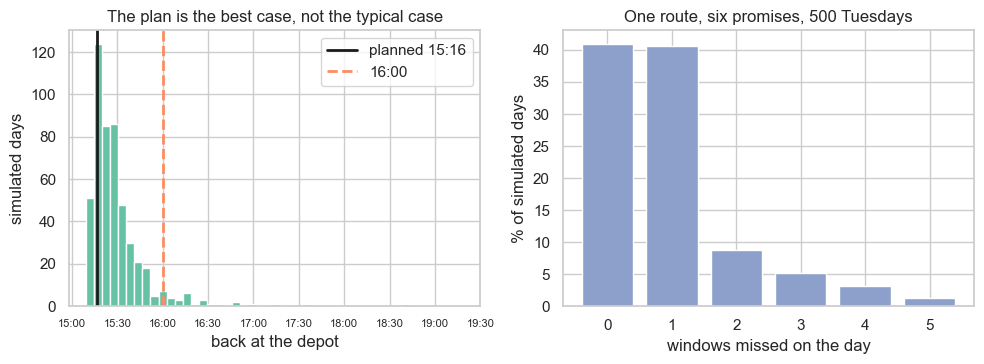

In [8]:
rng = np.random.default_rng(2024)
days = [walk(demo, tmult=rng.choice(err, len(demo) + 1)) for _ in range(500)]
sim = pd.DataFrame([(d["misses"], d["finish"]) for d in days], columns=["misses", "finish"])
print(f"P(at least one window missed) : {(sim.misses > 0).mean():6.1%}   (the plan says 0)")
print(f"P(home after 16:00)           : {(sim.finish > SHIFT_END).mean():6.1%}")
print(f"mean arrival back at the yard : {hhmm(sim.finish.mean())}   (the plan says {hhmm(w['finish'])})")

# FIG 3 -- what 'feasible on paper' is worth
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].hist(sim.finish, bins=40, color="#66c2a5", edgecolor="white")
axes[0].axvline(w["finish"], color="k", lw=2, label=f"planned {hhmm(w['finish'])}")
axes[0].axvline(SHIFT_END, color="#fc8d62", ls="--", lw=2, label="16:00")
ticks = np.arange(15 * 60, int(sim.finish.max()) + 60, 30)
axes[0].set_xticks(ticks)
axes[0].set_xticklabels([hhmm(m) for m in ticks], fontsize=8)
axes[0].set_xlabel("back at the depot"); axes[0].set_ylabel("simulated days")
axes[0].set_title("The plan is the best case, not the typical case")
axes[0].legend()

counts = sim.misses.value_counts().sort_index()
axes[1].bar(counts.index, counts.values / len(sim) * 100, color="#8da0cb")
axes[1].set_xlabel("windows missed on the day"); axes[1].set_ylabel("% of simulated days")
axes[1].set_title("One route, six promises, 500 Tuesdays")
plt.tight_layout()

**59 % of days miss at least one window** on a route whose plan misses none — and that is *before* anyone opens a wall and discovers the cable isn't where the drawing says.

The mechanism is worth naming precisely, because it is the reason this notebook exists. The plan's margins were 93, 18, 20, **3**, 35 and 76 minutes. A single leg running 39 % long (the 90th percentile — one leg in ten) adds roughly 8 minutes; two of them in a row adds 16; and stop 4 only had 3. The route did not fail because the model was bad. It failed because a plan built on **conditional means** is, by construction, the *best-case* schedule: it is feasible on the day where nothing runs long, and every day is a day where *something* runs long.

> ⚠️ **The planning error you will actually make.** Not "my travel-time model has 9 minutes of MAE". It is "I validated my schedule against the mean and shipped it as if it were a guarantee." A schedule needs to be checked against the *distribution* — which is precisely what §5 does, and what 🧪 Exercise 3's validator forgets to do.

---

### ✋ Quick exercise (~2 min) — walk the route by hand

A technician leaves the depot at **08:00**. Here is the sheet, with the planned travel time to each stop, the minutes on site, and the promised window:

| stop | travel to it (min) | on site (min) | window |
|---|---|---|---|
| A | 25 | 45 | 08:00–10:00 |
| B | 20 | 60 | 09:00–11:00 |
| C | 15 | 30 | 10:00–12:00 |
| D | 35 | 45 | 11:00–13:00 |

Compute the arrival time at each stop (a technician who arrives before the window opens **waits**), and find the **first violated window**. Then: how many minutes of delay on the *first* leg would it take to break stop C?

In [9]:
# ✍️ Your turn 👇
travel_to = [25, 20, 15, 35]          # minutes
on_site = [45, 60, 30, 45]            # minutes
opens = [8 * 60, 9 * 60, 10 * 60, 11 * 60]
closes = [10 * 60, 11 * 60, 12 * 60, 13 * 60]

t = 8 * 60
# for each stop: t = max(t + travel_to[i], opens[i]); check t <= closes[i]; then t += on_site[i]

<details>
<summary>✅ <b>Solution</b></summary>

```python
t = 8 * 60
for i, name in enumerate("ABCD"):
    t = max(t + travel_to[i], opens[i])
    status = "OK" if t <= closes[i] else "MISSED"
    print(f"{name}: arrive {t // 60:02d}:{t % 60:02d}  "
          f"window {opens[i] // 60:02d}:00-{closes[i] // 60:02d}:00  {status}  "
          f"margin {closes[i] - t:+4d} min")
    t += on_site[i]
```

A at 08:25 (margin 95), B at 09:30 (margin 90), C at 10:45 (margin 75), **D at 11:50 against a window that closes at 13:00 — margin 70. Nothing is violated on paper.** That is the point of the exercise: a hand-built route usually *is* feasible against mean times, and the only interesting question is *by how much*. The margins shrink monotonically down the route — 95, 90, 75, **70** — so the first window to break under a delay on leg 1 is **D**, at 70 minutes, and C follows at 75. The binding constraint sits at the **end** of the route, which is where accumulated delay lands and where a dispatcher's eye never goes.
</details>

## 3. The dumb baseline, and the wrong objective

Ask any optimiser to "plan the day" and it will ask you back: *minimise what?* The reflexive answer in logistics is **total distance**. It is the objective every textbook TSP uses, it is the one the fleet manager's dashboard shows, and it is very nearly always wrong.

The classical construction is **nearest neighbour**: whichever van is free earliest grabs the nearest unassigned job it is qualified for. Then we polish each route with **2-opt** — a local search that reverses a segment of the route and keeps the reversal if it shortens the trip (it is the move that un-crosses two crossing legs, and it is four lines of code). Nothing in that procedure has ever heard of a customer window.

In [10]:
def two_opt(route, cost, slack=0.0):
    """Local search: reverse route[i:k+1]; keep the reversal if `cost` improves.
    On a plain distance objective this is the move that un-crosses two crossing legs."""
    best, improved = cost(route, slack), True
    while improved:
        improved = False
        for i in range(len(route) - 1):
            for k in range(i + 1, len(route)):
                candidate = route[:i] + route[i:k + 1][::-1] + route[k + 1:]
                c = cost(candidate, slack)
                if c < best - 1e-9:
                    route, best, improved = candidate, c, True
    return route


def route_km(route, slack=0.0):
    return walk(route)["km"]


def money(km, misses, overtime, deferred=0):
    return KM_COST * km + MISS_COST * misses + OT_MIN * overtime + DEFER_COST * deferred


def score_plan(plan, slack=0.0):
    """Price a whole plan the way the P&L would."""
    km = ot = 0.0
    misses = 0
    for r in plan.values():
        s = walk(r, slack)
        km, misses, ot = km + s["km"], misses + s["misses"], ot + s["overtime"]
    deferred = N - sum(len(r) for r in plan.values())
    return dict(km=km, misses=misses, overtime=ot, deferred=deferred,
                eur=money(km, misses, ot, deferred))


def plan_nearest_neighbour():
    """Minimise kilometres. Windows are not in the objective, so they are not in the plan."""
    left = set(range(1, N + 1))
    routes = {t: [] for t in TECHS.tech}
    at = {t: 0 for t in TECHS.tech}
    clock = {t: float(SHIFT_START) for t in TECHS.tech}
    while left:
        free = [r for r in TECHS.itertuples() if any(SKILL[j] in r.skills for j in left)]
        r = min(free, key=lambda r: clock[r.tech])
        j = min((j for j in left if SKILL[j] in r.skills), key=lambda j: DIST[at[r.tech], j])
        clock[r.tech] += travel(at[r.tech], j, clock[r.tech]) + SERVICE[j]
        routes[r.tech].append(j)
        at[r.tech] = j
        left.discard(j)
    return {t: two_opt(r, route_km) for t, r in routes.items()}


plan_km_only = plan_nearest_neighbour()
s = score_plan(plan_km_only)
waiting = 0.0                      # how much of the day is spent at the kerb, not working
for route in plan_km_only.values():
    t, prev = float(SHIFT_START), 0
    for j in route:
        t += travel(prev, j, t)
        waiting += max(0.0, WOPEN[j] - t)
        t, prev = max(t, WOPEN[j]) + SERVICE[j], j
print(f"distance-optimal plan: {s['km']:.1f} km | windows hit {N - s['misses']}/{N} | "
      f"overtime {s['overtime']:.0f} min | EUR {s['eur']:,.0f}")
print(f"of which: driving EUR {KM_COST * s['km']:.0f}, window credits EUR {MISS_COST * s['misses']:,.0f}, "
      f"overtime EUR {OT_MIN * s['overtime']:.0f}")
print(f"the fleet spends {waiting / 60:.1f} hours parked at the kerb, waiting for windows to open")

distance-optimal plan: 287.1 km | windows hit 13/40 | overtime 1120 min | EUR 5,067
of which: driving EUR 121, window credits EUR 4,050, overtime EUR 896
the fleet spends 26.4 hours parked at the kerb, waiting for windows to open


Read that honestly, because the optimiser did nothing wrong. **287.1 km** is the shortest set of routes anything in this notebook produces. It is a genuinely good answer to the question it was asked.

It also **misses 27 of the 40 windows**. Not because the routing is stupid — because a spatially-ordered route arrives at each customer at a time that is essentially *independent* of that customer's window, and a two-hour window covers a quarter of an eight-hour day. Hitting 13 of 40 by accident is roughly what chance predicts. And the day runs **18.7 hours of overtime** across six vans, almost all of it accumulated *waiting*: a van that reaches a 14:00–16:00 customer at 09:30 sits at the kerb, and the fleet spends **26 hours parked** waiting for windows to open.

The whole ledger:

| | distance-optimal |
|---|---|
| driving | €121 |
| window credits | €4,050 |
| overtime | €896 |
| **total** | **€5,067** |

> ⚠️ **The failure mode, stated plainly.** An optimiser answers the question you actually asked, at industrial strength, with no judgement and no embarrassment. If the objective omits the promise, the plan will sell the promise for whatever it is worth in the objective — here, for **€4.60 of diesel**, because §4's euro-optimal plan drives only 11 km further. *"Minimise distance"* is not a simplification of *"run a good service business"*; it is a different business.

---

### ✋ Quick exercise (~2 min) — price the detour

The dispatcher is looking at one specific decision. Sending Bendix to a customer **9 km out of his way** (18 km round trip) would let him hit a window he would otherwise miss.

1. What does the detour cost in driving?
2. What does the missed window cost?
3. How many kilometres of detour would be *too many*?
4. And a harder one: the detour also adds ~35 minutes to his day, which lands in overtime. Does the answer change?

In [11]:
# ✍️ Your turn 👇
detour_km = 18.0
extra_minutes = 35.0
# compare KM_COST * detour_km (+ overtime) against MISS_COST
# break-even detour = ? km

<details>
<summary>✅ <b>Solution</b></summary>

```python
drive = KM_COST * detour_km
overtime = OT_MIN * extra_minutes
print(f"detour: EUR {drive:.2f} of driving + EUR {overtime:.2f} of overtime = EUR {drive + overtime:.2f}")
print(f"missed window: EUR {MISS_COST:.2f}")
print(f"break-even detour, driving only : {MISS_COST / KM_COST:,.0f} km")
print(f"break-even detour, incl. overtime: "
      f"{(MISS_COST - overtime) / KM_COST:,.0f} km")
```

The detour costs **€7.56** of diesel and **€28.00** of overtime — €35.56 all-in against a **€150** miss. Take it, and it is not close. On driving alone the break-even detour is **357 km**, which is longer than the entire fleet's day: at €0.42/km, *kilometres are almost never the binding cost in an urban service business*. Overtime is the constraint that actually bites (€48/h), and even including it the detour pays up to **290 km**. That ratio — one promise ≈ 357 km ≈ three hours of overtime — is the exchange rate §4's objective is built from, and it is why the distance-optimal plan is not a near-miss but a category error.
</details>

## 4. Optimising the thing you actually care about

A real routing problem has two layers, and it is worth keeping them apart because they need different tools.

**Layer 1 — assignment: who does what?** This is a matching problem, and matching problems have an exact polynomial solution: the **Hungarian algorithm**, shipped as `scipy.optimize.linear_sum_assignment`. The trick that makes a 40-jobs-to-6-technicians problem fit a one-to-one matcher is to **replicate each technician into time slots** — Elias-at-08:30, Elias-at-09:30, … — so the 40 jobs are matched against 48 (technician, slot) columns. The cost of putting job *j* in slot *(t, k)* is then a plain sum of what we care about: an impossible skill is priced at infinity, distance from the technician's patch is priced at what a kilometre of van-plus-technician actually costs, and a slot whose clock is nowhere near the job's window is priced against the window credit.

**Layer 2 — sequencing: in what order?** This is a travelling-salesman-with-time-windows problem, which is NP-hard, so we do what production systems do: build a decent route greedily, then improve it with local search. **Greedy insertion** takes the jobs in deadline order and drops each one into the cheapest position in the route so far; **2-opt** (already written in §3) then polishes.

The objective for both layers is the same, and it is the only one that matters: **euros**. Travel cost, plus window credits, plus overtime — and one more term the distance plan never had the option to use. If a job genuinely cannot be promised tomorrow, the optimiser may **hand it back**: phone the customer this evening, agree a slot for Wednesday, pay **€60** instead of €150. A promise you know you will break is worth breaking politely, in advance.

In [12]:
def assign_jobs(techs, slack=0.0, slots=8):
    """Layer 1: jobs -> (technician, time slot) by exact linear assignment."""
    cols = [(r.tech, r.skills, HOME[r.tech],
             SHIFT_START + (k + 0.5) * (SHIFT_END - SHIFT_START) / slots)
            for r in techs.itertuples() for k in range(slots)]
    C = np.empty((N, len(cols)))
    for j in range(1, N + 1):
        for c, (tech, skills, home, slot_clock) in enumerate(cols):
            if SKILL[j] not in skills:
                C[j - 1, c] = 1e6                       # a skill you don't have is infinite cost
                continue
            mismatch = max(WOPEN[j] - 30 - slot_clock, slot_clock - (WCLOSE[j] - slack), 0.0)
            C[j - 1, c] = (2 * 2.0 * DIST[home, j]           # ~EUR 2/km all-in, there and back
                           + MISS_COST * min(1.0, mismatch / 120))
    rows, chosen = linear_sum_assignment(C)               # exact, in milliseconds
    out = {t: [] for t in techs.tech}
    for j, c in zip(rows, chosen):
        out[cols[c][0]].append(j + 1)
    return out


def planned_cost(route, slack=0.0):
    s = walk(route, slack)
    return money(s["km"], s["misses"], s["overtime"])


def greedy_insertion(js, slack=0.0, cost=None):
    """Layer 2a: take jobs in deadline order, drop each into its cheapest position."""
    cost = cost or planned_cost
    route = []
    for j in sorted(js, key=lambda j: (WCLOSE[j], WOPEN[j])):
        route = min((route[:p] + [j] + route[p:] for p in range(len(route) + 1)),
                    key=lambda r: cost(r, slack))
    return route


def optimise(slack=0.0, techs=None, cost=None):
    """Assignment -> greedy insertion -> 2-opt -> hand back what cannot be promised."""
    techs = TECHS if techs is None else techs
    cost = cost or planned_cost
    groups = assign_jobs(techs, 0.0)
    routes = {t: two_opt(greedy_insertion(js, slack, cost), cost, slack)
              for t, js in groups.items()}
    changed = True
    while changed:                                        # removal pass: defer if it pays
        changed = False
        for t, r in routes.items():
            here = cost(r, slack)
            best = min(((cost([q for q in r if q != j], slack) + DEFER_COST, j) for j in r),
                       default=None)
            if best is not None and best[0] < here - 1e-9:
                routes[t] = two_opt([q for q in r if q != best[1]], cost, slack)
                changed = True
    return routes


plan_eur = optimise(0.0)
print({t: [NAME[j] for j in r] for t, r in plan_eur.items()})

{'Aylin': ['J39', 'J25', 'J38', 'J22', 'J24', 'J36'], 'Bendix': ['J01', 'J09', 'J29', 'J37', 'J05', 'J33', 'J32'], 'Cem': ['J31', 'J16', 'J10', 'J35', 'J19', 'J26'], 'Doro': ['J27', 'J18', 'J03', 'J15'], 'Elias': ['J06', 'J28', 'J08', 'J12', 'J04', 'J02', 'J11', 'J20'], 'Freya': ['J40', 'J07', 'J14', 'J23', 'J34', 'J21', 'J30', 'J17']}


In [13]:
def plan_dispatcher():
    """The spreadsheet, reconstructed: jobs in window order, each given to the
    nearest qualified technician who is not already the busiest."""
    routes = {t: [] for t in TECHS.tech}
    load = {t: 0.0 for t in TECHS.tech}
    for j in sorted(range(1, N + 1), key=lambda j: (WOPEN[j], -SERVICE[j])):
        eligible = [r for r in TECHS.itertuples() if SKILL[j] in r.skills]
        pick = min(eligible, key=lambda r: DIST[HOME[r.tech], j] + 0.06 * load[r.tech])
        routes[pick.tech].append(j)
        load[pick.tech] += SERVICE[j] + 20
    return routes


plan_manual = plan_dispatcher()

rows = []
for name, plan in [("distance-optimal", plan_km_only), ("dispatcher's plan", plan_manual),
                   ("euro-optimal", plan_eur)]:
    s = score_plan(plan)
    rows.append(dict(plan=name, km=round(s["km"], 1), promised=N - s["deferred"],
                     windows_hit=N - s["deferred"] - s["misses"], rebooked=s["deferred"],
                     overtime_min=round(s["overtime"]),
                     driving=round(KM_COST * s["km"]), credits=round(MISS_COST * s["misses"]),
                     overtime=round(OT_MIN * s["overtime"]),
                     rebooking=round(DEFER_COST * s["deferred"]), total=round(s["eur"])))
compare = pd.DataFrame(rows).set_index("plan")
print(compare.to_string())
print("\njobs per technician:", {t: len(r) for t, r in plan_eur.items()})

                      km  promised  windows_hit  rebooked  overtime_min  driving  credits  overtime  rebooking  total
plan                                                                                                                 
distance-optimal   287.1        40           13         0          1120      121     4050       896          0   5067
dispatcher's plan  379.9        40           31         0            40      160     1350        32          0   1542
euro-optimal       298.3        39           39         1            57      125        0        46         60    231

jobs per technician: {'Aylin': 6, 'Bendix': 7, 'Cem': 6, 'Doro': 4, 'Elias': 8, 'Freya': 8}


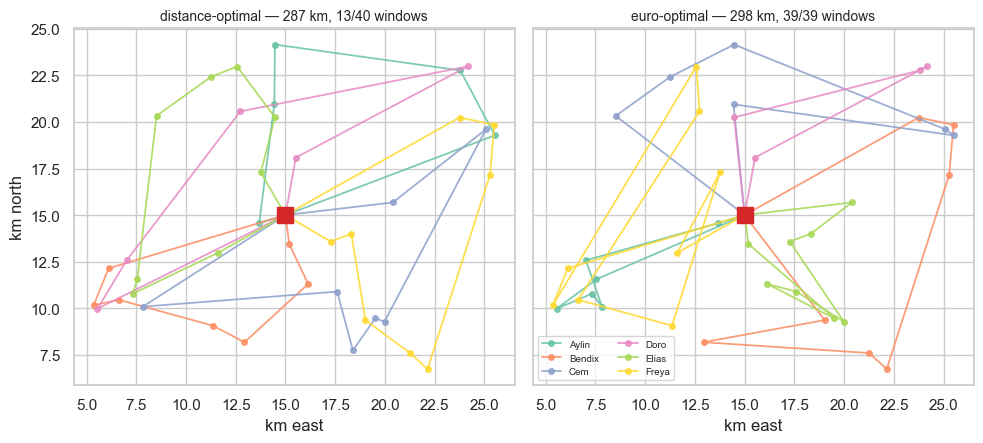

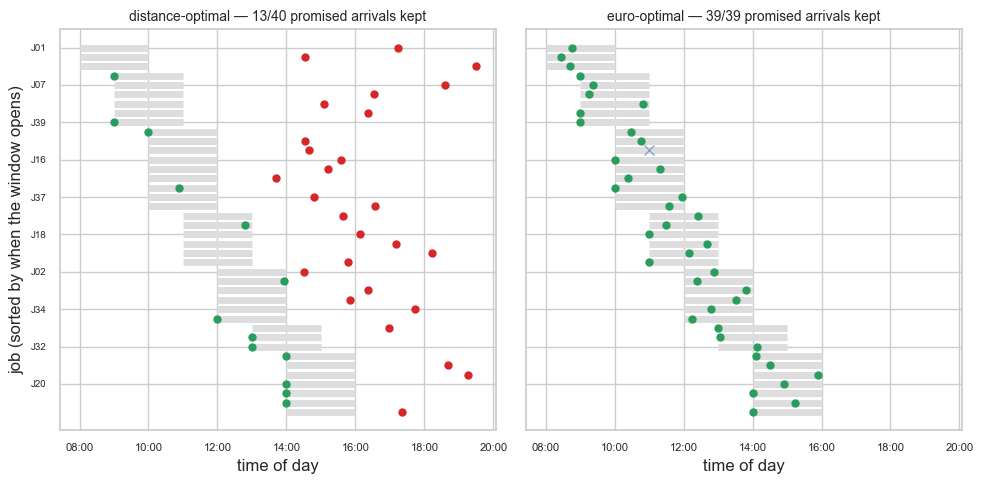

In [14]:
# FIG 4 -- the same 40 jobs, two objectives
COLOURS = dict(zip(TECHS.tech, ["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f"]))
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), sharex=True, sharey=True)
for ax, (title, plan) in zip(axes, [("distance-optimal — 287 km, 13/40 windows", plan_km_only),
                                    ("euro-optimal — 298 km, 39/39 windows", plan_eur)]):
    for tech, route in plan.items():
        path = [0] + route + [0]
        ax.plot(pts[path, 0], pts[path, 1], "-o", ms=4, lw=1.3,
                color=COLOURS[tech], alpha=0.85, label=tech)
    ax.scatter(*DEPOT, marker="s", s=140, color="#d62728", zorder=5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("km east")
axes[0].set_ylabel("km north")
axes[1].legend(fontsize=7, ncol=2, loc="lower left")
plt.tight_layout()

# FIG 5 -- the same two plans, drawn as promises instead of geography
order = sorted(range(1, N + 1), key=lambda j: (WOPEN[j], WCLOSE[j]))
row = {j: k for k, j in enumerate(order)}
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True, sharex=True)
for ax, (title, plan) in zip(axes, [("distance-optimal", plan_km_only), ("euro-optimal", plan_eur)]):
    for j in order:
        ax.plot([WOPEN[j], WCLOSE[j]], [row[j]] * 2, lw=5, color="#dddddd", solid_capstyle="butt")
    scheduled = set()
    for route in plan.values():
        for j, n, sc, a, m, late in walk(route)["stops"]:
            scheduled.add(j)
            ax.plot(a, row[j], "o", ms=5, color="#d62728" if late else "#2a9d5c", zorder=3)
    for j in set(order) - scheduled:
        ax.plot(np.mean([WOPEN[j], WCLOSE[j]]), row[j], "x", ms=7, color="#8da0cb", zorder=3)
    hit = sum(1 for r in plan.values() for st in walk(r)["stops"] if not st[5])
    ax.set_title(f"{title} — {hit}/{len(scheduled)} promised arrivals kept", fontsize=10)
    ax.set_xticks(np.arange(8 * 60, 20 * 60 + 1, 120))
    ax.set_xticklabels([hhmm(m) for m in np.arange(8 * 60, 20 * 60 + 1, 120)], fontsize=8)
    ax.set_xlabel("time of day")
axes[0].set_yticks(list(row.values())[::4])
axes[0].set_yticklabels([NAME[j] for j in order][::4], fontsize=7)
axes[0].set_ylabel("job (sorted by when the window opens)")
axes[0].invert_yaxis()
plt.tight_layout()

Three readings, in order of how much they cost:

1. **The euro-optimal plan drives 11 km further than the distance-optimal one and costs €4,836 less per day.** Same fleet, same jobs, same constraints — a different objective. The €4.60 of extra diesel is the cheapest purchase in this notebook.
2. **The dispatcher is not the villain.** Her plan hits 31 of 40 windows and runs almost no overtime; it loses on kilometres (379.9 vs 298.3 — the zig-zag you can see in the map's left panel is a chronological plan, which is a *temporal* ordering forced onto a *spatial* problem) and on the nine windows it drops. €1,542 against €231 is a real gap, but it is a gap between a competent human and an optimiser, not between negligence and competence. That distinction matters in §6.
3. **The second figure is the whole argument in one image.** Grey bars are the promises; dots are the planned arrivals. On the left they scatter across the day with no relationship to the bars at all — which is what "the objective did not contain the promise" looks like when you draw it. On the right every dot sits inside its bar, most of them near the *start*, and one job is an × because it was handed back. Two identical fleets, two objectives, and the difference is not subtle enough to argue about.
4. **The optimiser hands one job back.** `J13` is rebooked for Wednesday at €60 rather than attempted and missed at €150. Notice that this option was *available* to the distance-optimal plan too and it never used it — because in a distance objective, cancelling a job is pure profit and the constraint that stops it from cancelling everything doesn't exist. Objectives are not neutral; they decide which moves even look like moves.

And the plan looks *odd*. Doro has four jobs and Elias has eight. Aylin drives past two of Freya's stops. Every one of those oddities has a reason (skills, windows, patches) and none of them is visible on the map — which is §6's problem, and the bonus project's.

---

### ✋ Quick exercise (~2 min) — 2-opt by hand on five stops

A van leaves the depot (node 0), visits five customers in the order `[1, 2, 3, 4, 5]`, and returns. The road distances are below.

Apply one round of **2-opt**: for every pair `(i, k)`, reverse the segment `route[i:k+1]`, and keep the best improvement. What is the new order, and how much shorter is it?

In [15]:
# ✍️ Your turn 👇
D5 = np.array([                 # 0 = depot, 1..5 = customers
    [0, 4, 9, 5, 8, 6],
    [4, 0, 6, 3, 9, 8],
    [9, 6, 0, 7, 4, 3],
    [5, 3, 7, 0, 8, 9],
    [8, 9, 4, 8, 0, 5],
    [6, 8, 3, 9, 5, 0]], dtype=float)
tour = [1, 2, 3, 4, 5]

def tour_len(r):
    path = [0] + list(r) + [0]
    return sum(D5[path[i], path[i + 1]] for i in range(len(path) - 1))

print("start:", tour, tour_len(tour))
# try every reversal route[i:k+1] and keep the best

start: [1, 2, 3, 4, 5] 36.0


<details>
<summary>✅ <b>Solution</b></summary>

```python
best, best_len = list(tour), tour_len(tour)
for i in range(len(tour) - 1):
    for k in range(i + 1, len(tour)):
        cand = tour[:i] + tour[i:k + 1][::-1] + tour[k + 1:]
        if tour_len(cand) < best_len:
            best, best_len = cand, tour_len(cand)
print(f"best single reversal: {best}  length {best_len}  (was {tour_len(tour)})")

route = list(tour)                      # ...and run it to convergence, as two_opt() does
improved = True
while improved:
    improved = False
    for i in range(len(route) - 1):
        for k in range(i + 1, len(route)):
            cand = route[:i] + route[i:k + 1][::-1] + route[k + 1:]
            if tour_len(cand) < tour_len(route) - 1e-9:
                route, improved = cand, True
print(f"2-opt optimum: {route}  length {tour_len(route)}")
```

The starting tour is **36**. The best single reversal is `[1, 3, 2, 4, 5]` at **29** — it reverses the segment `[2, 3]`, un-crossing the legs `1→2` and `3→4`. Running to convergence lands on `[1, 3, 4, 2, 5]` at **28**, a **22 %** improvement from a move you can do on a whiteboard. (Brute-forcing all 120 permutations confirms 28 is the true optimum — on five stops 2-opt gets there; on twenty it will not, and it will not tell you.)

Two things to carry. 2-opt returns a **local** optimum, so where it stops depends on where it started — that is 🧪 Exercise 4. And on a *time-windowed* objective a reversal changes arrival times as well as distance, so `two_opt` in §3 re-evaluates the whole route rather than using the classic four-edge shortcut arithmetic; the four-edge trick is only valid when cost is a sum over edges, and window credits are not.
</details>

## 5. The plan that survives Tuesday

The euro-optimal plan costs **€231** on paper. That number is fiction, and §2 already told us why: it prices the day in which every leg takes exactly its predicted mean and every job takes exactly its estimate.

So let's stop reading plans off a sheet and start **simulating** them. Each simulated day draws every leg's travel time from §2's held-out error distribution and every job's duration from the workshop's own log (median 0.94× the estimate, 90th percentile 1.31×, and a tail where 7 % of jobs run more than a quarter-hour long). Four hundred Tuesdays per plan, the same four hundred for each plan so the comparison is fair.

In [16]:
SERVICE_ERR = (slog.actual_min / slog.est_min).to_numpy()


def simulate(plan, slack=0.0, draws=400, seed=99):
    """Run a plan against the measured travel-time and duration distributions."""
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(draws):
        km = ot = 0.0
        misses = 0
        for r in plan.values():
            s = walk(r, slack, rng.choice(err, len(r) + 1), rng.choice(SERVICE_ERR, len(r)))
            km, misses, ot = km + s["km"], misses + s["misses"], ot + s["overtime"]
        deferred = N - sum(len(r) for r in plan.values())
        out.append((km, misses, ot, money(km, misses, ot, deferred)))
    return pd.DataFrame(out, columns=["km", "misses", "overtime", "eur"])


rows = []
for name, plan in [("distance-optimal", plan_km_only), ("dispatcher's plan", plan_manual),
                   ("euro-optimal", plan_eur)]:
    s, mc = score_plan(plan), simulate(plan)
    rows.append(dict(plan=name, on_paper=round(s["eur"]), expected=round(mc.eur.mean()),
                     p90=round(mc.eur.quantile(.90)), worst=round(mc.eur.max()),
                     misses_planned=s["misses"], misses_expected=round(mc.misses.mean(), 2),
                     clean_days=f"{(mc.misses == 0).mean():.0%}"))
print(pd.DataFrame(rows).set_index("plan").to_string())

                   on_paper  expected   p90  worst  misses_planned  misses_expected clean_days
plan                                                                                          
distance-optimal       5067      5203  5353   5591              27            27.37         0%
dispatcher's plan      1542      2187  2660   3744               9            12.69         0%
euro-optimal            231       742  1250   1991               0             3.14         9%


There it is, and it is not a rounding error. The euro-optimal plan is priced at **€231** and costs **€742 on the average day** — it is out by a factor of three. Its 90th percentile is **€1,250**, and on **91 % of Tuesdays it misses at least one window it promised to hit**. Nine days out of a hundred go exactly to plan.

Notice which plan degrades *least* in relative terms: the distance-optimal one, from €5,067 to €5,203. It was already so bad that variance could barely make it worse — a plan that has given up on the windows has nothing left to lose. **Fragility is the price of tightness, and the euro-optimal plan is the tightest plan in the room.** It squeezed every minute of margin into either a shorter route or an extra job, because nothing in its objective valued margin.

Here is one of those Tuesdays, on one van, so the mechanism is visible rather than statistical:

In [17]:
# of 200 simulated Tuesdays, take the one with the worst single-van collapse and replay it
worst = None
for s_ in range(200):
    r_ = np.random.default_rng(s_)
    draws = {t: (r_.choice(err, len(r) + 1), r_.choice(SERVICE_ERR, len(r)))
             for t, r in plan_eur.items()}
    per_van = {t: walk(r, 0.0, *draws[t])["misses"] for t, r in plan_eur.items()}
    key = (max(per_van.values()), sum(per_van.values()))
    if worst is None or key > worst[0]:
        worst = (key, draws, per_van)

(van_worst, day_total), draws, per_van = worst
print(f"the worst of 200 Tuesdays: {day_total} windows missed fleet-wide "
      f"(the plan promised 0) -- {van_worst} of them on a single van\n")
for tech, route in plan_eur.items():
    if per_van[tech] < van_worst:
        continue
    planned, actual = walk(route), walk(route, 0.0, *draws[tech])
    print(f"{tech}'s day:")
    print(pd.DataFrame([dict(job=n, window=f"{hhmm(WOPEN[j])}-{hhmm(WCLOSE[j])}",
                             promised=hhmm(sc), arrived=hhmm(a2),
                             running_late=f"{a2 - sc:+.0f} min",
                             outcome="MISSED" if l2 else "ok")
                        for (j, n, sc, a, m, l), (_, _, _, a2, m2, l2)
                        in zip(planned["stops"], actual["stops"])]).to_string(index=False))
    print(f"back at the yard {hhmm(actual['finish'])} -- the sheet said {hhmm(planned['finish'])}")
    break

the worst of 200 Tuesdays: 9 windows missed fleet-wide (the plan promised 0) -- 6 of them on a single van

Freya's day:
job      window promised arrived running_late outcome
J40 08:00-10:00    08:41   08:44       +3 min      ok
J07 09:00-11:00    09:22   09:22       +0 min      ok
J14 09:00-11:00    10:49   13:53     +184 min  MISSED
J23 10:00-12:00    11:19   14:19     +179 min  MISSED
J34 12:00-14:00    12:48   15:59     +191 min  MISSED
J21 12:00-14:00    13:48   17:31     +223 min  MISSED
J30 14:00-16:00    15:13   18:42     +208 min  MISSED
J17 14:00-16:00    15:53   19:20     +207 min  MISSED
back at the yard 20:34 -- the sheet said 16:57


That is a **cascade**, and every field-service dispatcher has watched one happen. Freya's first two stops are on time to the minute. Then the leg to J14 meets an incident — the far right tail of §2's distribution, the one leg in a hundred that takes more than twice as long — and she arrives **three hours** late. Nothing recovers. The delay is now *in the schedule*: J23 is 179 minutes late, J34 is 191, J21 is 223, and the van is back at the yard at **20:34** against a sheet that said 16:57. One bad leg at 10:30 did not cost one window; it cost **every window after it** — six in a row, €900 on one van, on a day the plan scored as perfect.

That is the difference between a *forecast* error and a *plan* error. A travel-time model that is three hours wrong on one leg in a hundred still has an excellent MAE. A schedule that is three hours wrong on one leg in a hundred has a ruined day — because a schedule, unlike a forecast, has no mechanism for forgetting.

### Slack, and why the answer is not "as much as possible"

The fix is **slack**: buffer minutes written into every leg of the printed sheet. A plan with 12 minutes of slack per leg promises the customer 12 minutes later than the model's best guess, and a technician who is early waits. What that buys is *absorption* — a leg that runs 10 minutes long no longer moves anything downstream.

What it costs is **capacity**. Slack is time the fleet does not spend working, and this fleet is at 85 % utilisation, so the minutes have to come from somewhere. They come from jobs: with more slack, the optimiser finds that fewer of the 40 jobs fit inside a day it can honestly promise, and it hands more of them back at €60 each. **Slack is capacity you decline to sell.**

Which means there is an optimum, and it is interior. Sweep it.

In [18]:
sweep = []
for s_ in [0, 3, 6, 9, 12, 15, 18, 21, 25, 30, 40, 50]:
    plan = optimise(float(s_))
    paper, mc = score_plan(plan, float(s_)), simulate(plan, float(s_))
    sweep.append(dict(slack=s_, promised=N - paper["deferred"], rebooked=paper["deferred"],
                      on_paper=round(paper["eur"]), expected=round(mc.eur.mean()),
                      exp_misses=round(mc.misses.mean(), 2),
                      exp_overtime=round(mc.overtime.mean()),
                      p90=round(mc.eur.quantile(.90))))
sweep = pd.DataFrame(sweep).set_index("slack")
best_slack = int(sweep.expected.idxmin())
print(sweep.to_string())
print(f"\ncheapest slack: {best_slack} min/leg at EUR {sweep.expected.min():,.0f}/day "
      f"vs EUR {sweep.expected.loc[0]:,.0f} with none -- "
      f"EUR {sweep.expected.loc[0] - sweep.expected.min():,.0f}/day, "
      f"EUR {(sweep.expected.loc[0] - sweep.expected.min()) * 250:,.0f}/year")

       promised  rebooked  on_paper  expected  exp_misses  exp_overtime   p90
slack                                                                        
0            39         1       231       742        3.14           108  1250
3            38         2       251       552        1.83            33   906
6            37         3       320       570        1.48            42   923
9            36         4       384       561        1.05            50   866
12           35         5       421       548        0.70            29   784
15           35         5       458       593        0.78            68   861
18           34         6       549       681        0.76           103   886
21           31         9       683       722        0.21            58   840
25           30        10       723       758        0.19            40   879
30           30        10       723       763        0.20            43   891
40           29        11       845       875        0.16       

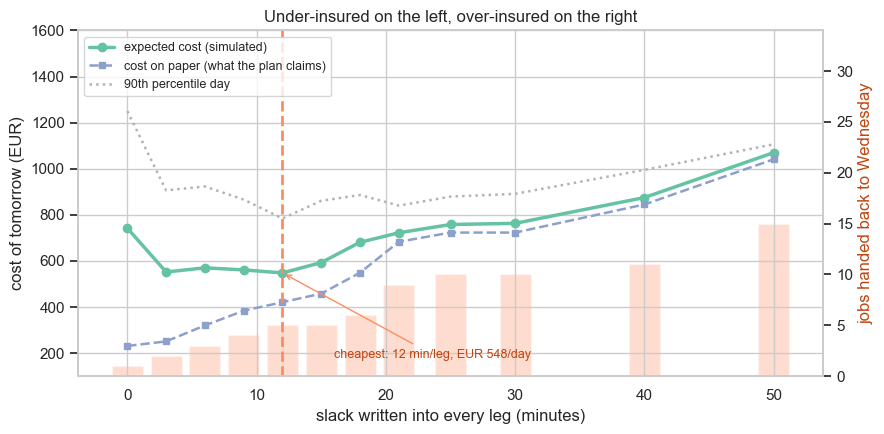

In [19]:
# FIG 5 -- the cost of insurance, and the cost of too much of it
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sweep.index, sweep.expected, "-o", color="#66c2a5", lw=2.5, label="expected cost (simulated)")
ax.plot(sweep.index, sweep.on_paper, "--s", color="#8da0cb", lw=1.8, ms=4,
        label="cost on paper (what the plan claims)")
ax.plot(sweep.index, sweep.p90, ":", color="#b3b3b3", lw=1.8, label="90th percentile day")
ax.axvline(best_slack, color="#fc8d62", ls="--", lw=2)
ax.annotate(f"cheapest: {best_slack} min/leg, EUR {sweep.expected.min():,.0f}/day",
            xy=(best_slack, sweep.expected.min()), xytext=(best_slack + 4, 180),
            arrowprops=dict(arrowstyle="->", color="#fc8d62"), fontsize=9, color="#c1440e")
ax.set_ylim(100, 1600)
ax2 = ax.twinx()
ax2.bar(sweep.index, sweep.rebooked, width=2.4, color="#fc8d62", alpha=0.30)
ax2.set_ylabel("jobs handed back to Wednesday", color="#c1440e")
ax2.set_ylim(0, 34)
ax2.grid(False)
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)
ax.set_xlabel("slack written into every leg (minutes)")
ax.set_ylabel("cost of tomorrow (EUR)")
ax.set_title("Under-insured on the left, over-insured on the right")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()

The curve is the section's argument in one picture.

- **Left of the optimum**, the plan is under-insured. At zero slack the sheet claims **€231** and the day costs **€742**, because the plan is a best case sold as a commitment.
- **At 12 minutes per leg**, expected cost bottoms out at **€548** — €194 a day, **€48,500 a year**, from a change that alters no model, buys no vehicle and hires nobody. The plan promises 35 jobs instead of 39, rebooks five, and now **hits every window on 60 % of days** instead of 9 %. Its 90th percentile falls from €1,250 to €784: the bad days get much better, which is the actual product.
- **Right of the optimum**, the insurance costs more than the risk. At 50 minutes per leg the optimiser hands back 15 of 40 jobs and expected cost is **€1,070** — worse than having no slack at all. You have bought a schedule that never fails because it barely promises anything.

Notice the dashed line. **The on-paper cost rises monotonically with slack** — a dispatcher optimising the sheet in front of her would choose zero every single time, and the sheet would agree with her every single time. The only way to see the real curve is to simulate; there is no amount of staring at a plan that reveals its variance.

> 🧠 **Third time this module.** A3 §5 bought credit limits that cut expected loss and cost a quarter of the profit. A8 §5 paid a dual-sourcing premium above the actuarial price. Here we hand back five jobs a day to protect thirty-five. The pattern is always the same: **you give up expected value to buy down variance, the price is visible and the benefit is not, and the number that decides it comes from simulating the bad case rather than from arguing about it.** The reason it keeps recurring is that it is the one calculation businesses reliably get wrong in the direction of buying too little.

Tomorrow's sheet, then — the actual deliverable:

In [20]:
final = optimise(float(best_slack))
mc_final = simulate(final, float(best_slack))

sheet = pd.DataFrame([
    dict(technician=tech, stop=k + 1, job=NAME[j],
         window=f"{hhmm(WOPEN[j])}-{hhmm(WCLOSE[j])}", eta=hhmm(sched[k]),
         minutes=int(SERVICE[j]), skill=SKILL[j], sla=jobs.sla[j - 1])
    for tech, route in final.items()
    for sched in [timetable(route, float(best_slack))]
    for k, j in enumerate(route)])
rebooked = [NAME[j] for j in range(1, N + 1) if not any(j in r for r in final.values())]

print(sheet.head(14).to_string(index=False))
print(f"\n... {len(sheet)} jobs scheduled across {sheet.technician.nunique()} technicians")
print(f"rebooked for Wednesday ({len(rebooked)}): "
      f"{', '.join(f'{d} ({jobs.sla[int(d[1:]) - 1]})' for d in rebooked)}")
print(f"\nexpected: EUR {mc_final.eur.mean():,.0f}/day | "
      f"{mc_final.misses.mean():.2f} windows missed | "
      f"{mc_final.overtime.mean():.0f} min overtime | "
      f"a clean day {(mc_final.misses == 0).mean():.0%} of the time")

technician  stop job      window   eta  minutes       skill      sla
     Aylin     1 J39 09:00-11:00 09:00       60 workstation business
     Aylin     2 J25 10:00-12:00 10:34       60 workstation standard
     Aylin     3 J38 10:00-12:00 11:58       30     network business
     Aylin     4 J22 11:00-13:00 12:45       45     network business
     Aylin     5 J24 13:00-15:00 13:52       30 workstation standard
     Aylin     6 J36 14:00-16:00 14:45       45     network business
    Bendix     1 J01 08:00-10:00 08:57       20     printer standard
    Bendix     2 J09 09:00-11:00 09:39       30     printer  premium
    Bendix     3 J37 10:00-12:00 11:01       20 workstation standard
    Bendix     4 J29 11:00-13:00 12:00       30     printer standard
    Bendix     5 J05 12:00-14:00 13:10       45 workstation standard
    Bendix     6 J32 13:00-15:00 14:18       45 workstation standard
       Cem     1 J31 09:00-11:00 09:00       20     network business
       Cem     2 J16 10:00-12:00 1

That is the object this notebook was for: not a score, not a ranking, not a threshold — **a table a human can execute**, with a promised time next to every job, five names to phone this evening, and a defensible number attached to the whole thing.

One detail worth defending before §6, because the dispatcher will ask about it: the five rebooked jobs are `J12` (business), `J13`, `J14`, `J21` and `J33` (standard). The optimiser did not pick them because they are unimportant — it picked them because they were the jobs whose promises were most expensive to keep given everything else. Nothing in this objective knows that a **premium** contract's window is worth more than a standard one's; every miss is priced at the same €150. That is a modelling choice, it is visible in the code, and 🧠 Stretch B changes it and watches a different five jobs fall out.

---

### ✋ Quick exercise (~2 min) — read the curve

Using the `sweep` table above (don't re-run the optimiser — just read it):

1. What does the *first* three minutes of slack per leg buy, in euros of expected cost per day?
2. Between 12 and 25 minutes of slack, expected misses keep falling. Why does expected **cost** rise anyway?
3. The finance director says: *"the P&L only shows the paper number — pick the slack that minimises that."* What does she choose, and what does it cost her?

In [21]:
# ✍️ Your turn 👇
view = sweep[["on_paper", "expected", "exp_misses", "rebooked"]]
print(view)
# 1. expected[0] - expected[3] = ?
# 2. look at the 'rebooked' column between slack 12 and 25
# 3. sweep.on_paper.idxmin() -> and what is `expected` at that slack?

       on_paper  expected  exp_misses  rebooked
slack                                          
0           231       742        3.14         1
3           251       552        1.83         2
6           320       570        1.48         3
9           384       561        1.05         4
12          421       548        0.70         5
15          458       593        0.78         5
18          549       681        0.76         6
21          683       722        0.21         9
25          723       758        0.19        10
30          723       763        0.20        10
40          845       875        0.16        11
50         1041      1070        0.12        15


<details>
<summary>✅ <b>Solution</b></summary>

```python
print(f"1. first 3 min of slack: EUR {sweep.expected.loc[0] - sweep.expected.loc[3]:,.0f}/day "
      f"for one extra rebooking")
print(f"2. slack 12 -> 25: misses {sweep.exp_misses.loc[12]:.2f} -> {sweep.exp_misses.loc[25]:.2f}, "
      f"but rebookings {sweep.rebooked.loc[12]} -> {sweep.rebooked.loc[25]} "
      f"(EUR {DEFER_COST * (sweep.rebooked.loc[25] - sweep.rebooked.loc[12]):,.0f} of rebooking)")
paper_pick = int(sweep.on_paper.idxmin())
print(f"3. she picks {paper_pick} min; it costs "
      f"EUR {sweep.expected.loc[paper_pick] - sweep.expected.min():,.0f}/day more than the honest choice")
```

1. **€190 a day** — the single best-value purchase on the curve, bought for one extra rebooking. Insurance is cheapest at the start, exactly as in A3 §5's limit bands.
2. Expected misses fall from **0.70 to 0.19**, worth about €77 a day at €150 each — but the rebookings needed to buy that go from **5 to 10**, which costs €300. You are paying €300 to save €77. *The marginal miss you are still buying out is the expensive one*, which is what an interior optimum means.
3. She picks **zero slack** (€231 on paper, the minimum of the dashed line) and it costs **€194 a day**, €48,500 a year. The paper number is not merely imprecise — it is *monotonically misleading*, so optimising it drives you to the corner every time. This is the same disease as A7's CRM rollup and A6's due-date accounting: a number that is wrong in a consistent direction is worse than a number that is noisy.
</details>

## 6. What real routing systems add (honest section)

Everything above is the load-bearing 80 %, and it is genuinely enough to beat a spreadsheet by €400k a year on one small fleet. Here is what a production system adds, and what this notebook did not solve.

- **A real solver.** Greedy insertion + 2-opt is a teachable local search, not a state of the art. Production teams use a dedicated VRP engine — **Google OR-Tools' routing library** is the standard free one — which handles capacities, pickup-and-delivery pairs, multiple depots, breaks, and soft time windows in one model, with metaheuristics (guided local search, large-neighbourhood search) that escape the local optima 2-opt sits in. *(No install, no code here: the point is that the model you formulated in §4 is the input to that solver, and formulating it correctly is the part that does not come from a library.)*
- **Real road networks and live traffic.** Our distances are straight lines × 1.25 and our travel times come from a model of our own history. Real systems query a road-network matrix (OSRM, Valhalla, or a commercial traffic API), which knows about one-way streets, bridges and the accident that just happened on the ring road. §2's error distribution would tighten considerably — and §5's argument would not change at all, because the residual would still be right-skewed and would still accumulate.
- **Intraday re-optimisation.** We planned once, at 18:00 the evening before, and then watched the plan degrade. Real dispatch re-optimises continuously: at 10:30, when a job over-runs by 90 minutes, the right question is not "how late is everyone now" but "given where all six vans actually are, what is the cheapest completion of today?" That is the same optimiser with a different starting state, and it is 🧠 Stretch D.
- **Service-time models.** We treated `service_min` as given and its error as noise. A real system predicts duration from job type, equipment, site history and technician — the same modelling exercise as §2, on the variable that §5 showed matters just as much.
- **Fairness, preferences and the roster.** Our objective has no opinion about Doro getting four jobs while Elias gets eight, or about whose day ends in traffic every night. Real systems carry workload-balance terms, seniority rules, lunch breaks, and union agreements — and they carry them because a schedule is also a workplace.
- **The adoption point, which is the one that actually kills projects.** A better schedule the dispatcher refuses to run is worth **nothing**. Every plan in §4 looks wrong somewhere: a van driving past a job it isn't doing, a technician with half a day, a customer rebooked for no visible reason. If the system cannot say *"Aylin passes J17 because only Cem is certified for it and he is across town"*, the dispatcher will override it — and each override is uncosted, so the plan degrades toward the spreadsheet she trusts. **The deliverable is not the schedule. It is the schedule plus the explanation.** That is why the bonus project is a dispatch sheet *and* a note.

Two honest omissions on top of those: our objective is a single day, so rebooking a job is priced at €60 rather than at what it does to Wednesday's board (a proper model plans a rolling horizon); and every miss costs the same €150 regardless of contract, which is wrong in a way Stretch B measures.

## 🧠 The story so far — one screen

| # | The move | The number that carries it |
|---|---|---|
| 1 | 40 jobs, 6 vans, 2-hour promises; 24.3 h of work in 48 h of fleet time | ~85 % utilisation once driving is counted |
| 2 | Travel-time model beats the dispatcher's 30 km/h rule | MAE **9.20** vs 11.35 min (flat baseline 17.59) |
| 2 | …and the mean is the wrong summary: errors are skewed and **accumulate** | ratio median 0.95, 90th pct **1.39**, 99th 2.25 |
| 2 | A route that is feasible on paper, simulated 500 times | **59 %** of days miss a window the plan hits |
| 3 | Nearest-neighbour, distance-minimising: the shortest plan there is | **287.1 km**, **13/40** windows, 26 h parked waiting, **€5,067** |
| 3 | The exchange rate that makes it absurd | one window = **€150** = **357 km** of driving |
| 4 | `linear_sum_assignment` (jobs→technician) + greedy insertion + 2-opt, on euros | **298.3 km**, 39 promised, **39 hit**, **€231** on paper |
| 4 | Against the dispatcher's spreadsheet | €1,542 — a competent human, beaten by €1,300/day |
| 5 | Simulate all three against measured travel + duration error | euro-optimal **€231 → €742**, 90th pct €1,250, worst €1,991, **9 %** clean days |
| 5 | One incident at 10:30 cascades down a route | +184 min → **six windows lost in a row**, home 20:34 |
| 5 | Sweep slack; the optimum is **interior** | **12 min/leg → €548/day**, 60 % clean days, **€48.5k/year** |
| 5 | The paper number is monotonically misleading | minimising it picks slack = 0 and costs €194/day |

## 🧪 Practice exercises

### Exercise 1 — ⭐ The price of the promise

The €150 miss cost carries the whole notebook. Put it on trial: re-price all three §4 plans with a window credit of €0, €20, €40, €60, €100 and €150 (leave driving and overtime as they are). At what price does the distance-optimal plan stop being embarrassing? Does the ranking of the three plans ever change?

Then answer in one sentence: what does the €0 column tell you about *why* the distance-optimal plan loses?

In [22]:
# Starter
# for m in [0, 20, 40, 60, 100, 150]:
#     cost = KM_COST * km + m * misses + OT_MIN * overtime + DEFER_COST * deferred

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
rows = []
for m in [0, 20, 40, 60, 100, 150]:
    row = {"miss_cost": m}
    for name, plan in [("distance", plan_km_only), ("dispatcher", plan_manual), ("euro", plan_eur)]:
        s = score_plan(plan)
        row[name] = round(KM_COST * s["km"] + m * s["misses"]
                          + OT_MIN * s["overtime"] + DEFER_COST * s["deferred"])
    rows.append(row)
print(pd.DataFrame(rows).set_index("miss_cost").to_string())
```

**The ranking never changes, and the €0 column is why.** With windows priced at nothing, the distance-optimal plan still costs **€1,017** against the dispatcher's €192 and the euro plan's €231 — because 26 hours of parked waiting turns into €896 of overtime. The plan that minimises kilometres does not even minimise *cost given free windows*; it minimises one line of a three-line P&L and lets the other two run. Every €20 you add to the credit then costs it another €540 (27 misses), so by €150 it is 22× the euro plan.

The general lesson is worth more than the arithmetic: when an objective omits a cost, the optimiser does not merely ignore that cost — it *spends* it, because spending it is now free. Distance-minimisation didn't accidentally miss 27 windows; it sold them.
</details>

### Exercise 2 — ⭐⭐ What is cross-training worth?

Cem does `network` only; Doro does `workstation` only. HR quotes **€4,200** per technician for a multi-skill certification course. Re-solve tomorrow at the chosen slack with every technician qualified for everything, simulate it, and turn the difference into a payback period. Then say what this estimate is *not* (hint: it is one day, and it is one seed).

In [23]:
# Starter
# flexible = TECHS.copy(); flexible["skills"] = [{"network", "workstation", "printer"}] * len(TECHS)
# optimise(float(best_slack), techs=flexible) ... simulate ... compare

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
flexible = TECHS.copy()
flexible["skills"] = [{"network", "workstation", "printer"} for _ in range(len(TECHS))]
plan_flex = optimise(float(best_slack), techs=flexible)
mc_flex = simulate(plan_flex, float(best_slack))

gain = mc_final.eur.mean() - mc_flex.eur.mean()
print(f"as-is      : EUR {mc_final.eur.mean():,.0f}/day, {N - sum(len(r) for r in final.values())} rebooked")
print(f"cross-trained: EUR {mc_flex.eur.mean():,.0f}/day, "
      f"{N - sum(len(r) for r in plan_flex.values())} rebooked")
print(f"gain EUR {gain:,.0f}/day = EUR {gain * 250:,.0f}/year -> "
      f"payback on 2 x EUR 4,200 in {2 * 4200 / (gain * 250) * 12:.1f} months")
```

A fully cross-trained fleet costs **€416 a day** against **€548** — **€131 a day, €32,800 a year** — and the two courses pay for themselves in **3.1 months**. The mechanism is visible in the plan: the skill constraint is what forces Doro's four-job day and Cem's detours, and removing it lets the assignment layer give every job to the van that is already nearby. One of the five rebooked jobs comes back into the day as well.

What this is *not*: it is one day's board, generated from one seed, and the gain depends entirely on how the skill mix happens to line up with the geography that day. A defensible business case re-runs `build_jobs(seed=...)` over fifty boards and quotes a distribution — which is Stretch C's habit applied here, and about six lines of work. It also ignores that a technician in a classroom is a technician not in a van.
</details>

### Exercise 3 — ⭐⭐ Debug me 🐞: the schedule that validated perfectly

A colleague built a feasibility checker and used it to sign off tomorrow's plan. It reports **40/40 windows feasible, no overtime, ship it**. Then the plan runs and the day falls apart exactly as §5 predicted. Their checker is below. Find the two bugs, and say which one is the *dangerous* one.

```python
def validate(plan):
    # check every job is reachable inside its window
    ok = True
    for tech, route in plan.items():
        t, prev = SHIFT_START, 0
        for j in route:
            t += trips.travel_min.mean()          # average travel time between jobs
            if t > WCLOSE[j]:
                print(f"{tech}: {NAME[j]} infeasible")
                ok = False
        if t > SHIFT_END:
            print(f"{tech}: overtime")
    return ok
```

In [24]:
# Starter -- run their checker on the dispatcher's plan and enjoy the green light
# (then fix it: service durations, window opening times, per-leg predictions, and a distribution)

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def validate_fixed(plan, slack=0.0, draws=200, target=0.90, seed=7):
    # feasible = arrives inside the window on `target` of simulated days
    rng = np.random.default_rng(seed)
    hits = {j: 0 for r in plan.values() for j in r}
    for _ in range(draws):
        for route in plan.values():
            s = walk(route, slack, rng.choice(err, len(route) + 1),
                     rng.choice(SERVICE_ERR, len(route)))
            for j, n, sc, a, m, late in s["stops"]:
                hits[j] += (not late)
    weak = {NAME[j]: h / draws for j, h in hits.items() if h / draws < target}
    print(f"jobs kept below {target:.0%} of the time: {len(weak)}")
    print(dict(sorted(weak.items(), key=lambda kv: kv[1])[:6]))
    return not weak


print("their checker on the dispatcher's plan:", end=" ")
t, prev = SHIFT_START, 0                       # the two bugs, reproduced
for j in plan_manual["Elias"]:
    t += trips.travel_min.mean()
print(f"Elias finishes at {hhmm(t)} -- 'no overtime'")
print("actual planned finish:", hhmm(walk(plan_manual['Elias'])["finish"]))
validate_fixed(plan_eur, 0.0)
```

**Bug 1 (visible): the clock never advances for the work itself.** `t += travel` and nothing else — `SERVICE[j]` is missing, and so is the wait for a window that has not opened yet. The checker has Elias home at **12:54**; his own plan says **15:44**. This bug is loud, and it is the one that gets caught in code review.

**Bug 2 (the dangerous one): it validates against a single average.** Even with the service times put back, `trips.travel_min.mean()` is one flat number for every leg — no distance, no departure hour, no distribution. Feasibility against *a* mean is not feasibility. §5 already measured what that is worth: the euro-optimal plan is 100 % feasible against means and misses a window on **91 % of days**. Run the fixed version and **10 of its 39 promises are kept less than 90 % of the time**, one of them (J17) only **32 %** — those ten were invisible to a boolean checker and are exactly the ones a dispatcher should be told about.

A schedule is feasible at a **service level**, not as a `True`. The first bug gets caught in review; the second one *passes* review, ships, and then gets blamed on traffic. Note how exactly it rhymes with NB 26: safety stock exists because "feasible against mean demand" is a stockout half the time.

</details>

### Exercise 4 — ⭐⭐ Does the insertion order matter?

`greedy_insertion` takes jobs in **deadline order** (`WCLOSE`, then `WOPEN`). Construction heuristics are notoriously sensitive to that choice. Re-run the sequencing layer for one technician with three orderings — deadline (the default), longest-service-first, and five random shuffles — both *before* and *after* 2-opt, and report planned cost. Does 2-opt rescue a bad start?

In [25]:
# Starter
# jobs_for = assign_jobs(TECHS, 0.0)["Elias"]
# build routes by inserting in a given order, then compare planned_cost before/after two_opt

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def insert_in_order(order, slack=0.0):
    route = []
    for j in order:
        route = min((route[:p] + [j] + route[p:] for p in range(len(route) + 1)),
                    key=lambda r: planned_cost(r, slack))
    return route


js = assign_jobs(TECHS, 0.0)["Elias"]
rng4 = np.random.default_rng(11)
orders = [("deadline", sorted(js, key=lambda j: (WCLOSE[j], WOPEN[j]))),
          ("longest first", sorted(js, key=lambda j: -SERVICE[j]))]
orders += [(f"random {i + 1}", list(rng4.permutation(js))) for i in range(5)]

out = []
for label, order in orders:
    raw = insert_in_order(order)
    out.append(dict(order=label, before=round(planned_cost(raw), 1),
                    after=round(planned_cost(two_opt(list(raw), planned_cost)), 1)))
print(pd.DataFrame(out).set_index("order").to_string())
```

The verdict is not the one the folklore predicts. Deadline order is the **worst** starting point here (**25.0**, because inserting in deadline order forces an expensive early sequence), every other ordering starts between **15.8 and 16.3** — and after 2-opt **all seven land on exactly 15.8**. On a route this short the polish does all the work and the construction rule is decoration.

Read that with its scope attached, because both halves are true and neither generalises for free. 2-opt returns a **local** optimum, so in general where it stops depends on where it started (that is why §6 lists metaheuristics at all) — but a six-or-seven-stop neighbourhood is small enough that 2-opt sweeps most of it, so the local optima coincide. Re-run this on a 20-stop route and the spread reappears immediately. The industrial answer to that is to randomise on purpose — many randomised constructions, keep the best (GRASP), or accept occasional worsening moves to escape a basin (simulated annealing) — a dozen lines on top of what you already have, and exactly what §6's "metaheuristics" means in practice.
</details>

## 🧠 Stretch exercises

### Stretch exercise A — ⭐⭐⭐ Start the vans from home

Technicians currently collect their van at the depot at 08:00 and return it at 16:00. The operations manager wants to try **take-home vans**: everyone starts and ends at their own address (nodes `HOME[tech]` already exist in the distance matrix). Re-solve at the chosen slack with per-technician start and end nodes, and price the change — kilometres, expected cost, and the number of windows kept. Then name the two costs of take-home vans that this model *cannot* see.

In [26]:
# Starter -- walk() already takes start=/end=/t0=; you need cost functions that pass them through
# def planned_cost_home(route, slack=0.0, home=0): ... walk(route, slack, start=home, end=home)

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def optimise_home(slack=0.0):
    groups = assign_jobs(TECHS, 0.0)
    routes = {}
    for tech, js in groups.items():
        h = HOME[tech]

        def cost(route, sl=slack, h=h):
            s = walk(route, sl, start=h, end=h)
            return money(s["km"], s["misses"], s["overtime"])

        r = []
        for j in sorted(js, key=lambda j: (WCLOSE[j], WOPEN[j])):
            r = min((r[:p] + [j] + r[p:] for p in range(len(r) + 1)), key=cost)
        r, changed = two_opt(r, cost, slack), True
        while changed:                                  # the same removal pass optimise() runs
            changed = False
            drop = min(((cost([q for q in r if q != j]) + DEFER_COST, j) for j in r), default=None)
            if drop is not None and drop[0] < cost(r) - 1e-9:
                r, changed = two_opt([q for q in r if q != drop[1]], cost, slack), True
        routes[tech] = r
    return routes


def simulate_home(plan, slack=0.0, draws=400, seed=99):
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(draws):
        km = ot = 0.0
        misses = 0
        for tech, r in plan.items():
            h = HOME[tech]
            s = walk(r, slack, rng.choice(err, len(r) + 1), rng.choice(SERVICE_ERR, len(r)),
                     start=h, end=h)
            km, misses, ot = km + s["km"], misses + s["misses"], ot + s["overtime"]
        out.append(money(km, misses, ot, N - sum(len(r) for r in plan.values())))
    return pd.Series(out)


home_plan = optimise_home(float(best_slack))
mc_home = simulate_home(home_plan, float(best_slack))
km_home = sum(walk(r, start=HOME[t], end=HOME[t])["km"] for t, r in home_plan.items())
print(f"depot start : EUR {mc_final.eur.mean():,.0f}/day, "
      f"{score_plan(final, float(best_slack))['km']:.0f} km, "
      f"{N - sum(len(r) for r in final.values())} rebooked")
print(f"home start  : EUR {mc_home.mean():,.0f}/day, {km_home:.0f} km, "
      f"{N - sum(len(r) for r in home_plan.values())} rebooked")
```

Take-home vans **lose here, and only just**: **€581 a day against €548**, 309 km against 285, and one extra job pushed to Wednesday. The reason is structural rather than unlucky. This depot sits in the middle of the map, so nobody's outbound leg is long; the technicians' addresses sit at the *edges* of their patches; and the assignment layer has already given each van a geographically coherent set of jobs, so the depot was never the thing costing money. Note also what the change does to the 08:00 leg — the most expensive minutes of the day at §2's rush-hour speeds — which is where the extra 24 km lands.

Move the depot to a ring-road industrial estate, or spread the patches further apart, and the sign flips. The point of building the model is that this is now a ten-second question instead of a meeting.

The two costs this model cannot see: **the van as an asset** (parking, insurance, security, and the private-use tax treatment a German employer has to handle), and **the depot's other functions** — parts, returns, and the informal handover where one technician tells another what she found in a customer's comms cabinet. A model that only optimises driving can never recommend against take-home vans for the right reason.
</details>

### Stretch exercise B — ⭐⭐⭐ Not every promise is worth the same

Every miss currently costs €150. In reality the SLA classes differ: say **standard €150**, **business €260**, **premium €420** (bigger credits, bigger accounts, louder escalations). Re-solve with an SLA-weighted objective, and compare against the flat plan on: total expected cost under the *weighted* prices, misses by class, and *which* jobs get rebooked. Does the flat-price plan look expensive once you price the promises properly?

In [27]:
# Starter
# SLA_MISS = {"standard": 150.0, "business": 260.0, "premium": 420.0}
# write cost_sla(route, slack) using walk(...)["stops"] -> (j, name, sched, arrival, margin, late)

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
SLA_MISS = {"standard": 150.0, "business": 260.0, "premium": 420.0}
JOB_MISS = np.r_[0.0, jobs.sla.map(SLA_MISS).to_numpy(), np.zeros(len(TECHS))]
JOB_DEFER = JOB_MISS * (DEFER_COST / MISS_COST)


def cost_sla(route, slack=0.0):
    s = walk(route, slack)
    return (KM_COST * s["km"] + OT_MIN * s["overtime"]
            + sum(JOB_MISS[j] for j, n, sc, a, m, late in s["stops"] if late))


def price_sla(plan, slack=0.0, draws=400, seed=99):
    rng = np.random.default_rng(seed)
    scheduled = {j for r in plan.values() for j in r}
    defer_bill = sum(JOB_DEFER[j] for j in range(1, N + 1) if j not in scheduled)
    tot, by_class = [], {c: 0.0 for c in SLA_MISS}
    for _ in range(draws):
        bill = defer_bill
        for r in plan.values():
            s = walk(r, slack, rng.choice(err, len(r) + 1), rng.choice(SERVICE_ERR, len(r)))
            bill += KM_COST * s["km"] + OT_MIN * s["overtime"]
            for j, n, sc, a, m, late in s["stops"]:
                if late:
                    bill += JOB_MISS[j]
                    by_class[jobs.sla[j - 1]] += 1 / draws
        tot.append(bill)
    return np.mean(tot), by_class


plan_sla = optimise(float(best_slack), cost=cost_sla)
for label, plan in [("flat EUR 150 plan", final), ("SLA-weighted plan", plan_sla)]:
    cost, by_class = price_sla(plan, float(best_slack))
    reb = [NAME[j] for j in range(1, N + 1) if not any(j in r for r in plan.values())]
    print(f"{label:18s} EUR {cost:,.0f}/day | misses by class "
          f"{ {k: round(v, 2) for k, v in by_class.items()} } | rebooked {reb}")
```

Priced properly, the flat plan costs **€657 a day** and the SLA-aware one **€613** — **€44 a day, €11,000 a year**, for a change that is one line of the objective and no new algorithm. The mechanism is visible in the rebooking list: the flat plan hands back **J12, a business job**, because geometry said so; the weighted plan hands back **J02, a standard one**, and keeps the business promise. Nothing else about the two plans differs materially, including the miss counts by class — which is the honest version of this result: most of the gain is in *which* promises get broken, not in how many.

The general point is the module's oldest: **the objective is the product.** Everything from §4 onward — the assignment costs, the insertion order, the slack level — is machinery that faithfully delivers whatever you put in the objective function, and the single highest-leverage hour of work in a routing project is the hour spent with the commercial team turning contracts into euros per broken promise. (And note what this exercise did *not* need: a new algorithm.)
</details>

### Stretch exercise C — ⭐⭐⭐ Should we hire a seventh technician?

Add **Gitte** — all three skills, patch at (19, 17) — and drop the last row of `TECHS` to get a five-van fleet, so you can price 5, 6 and 7 technicians at the chosen slack. A fully-loaded technician plus van costs **€68,000 a year**. Where is the break-even, and what would change your answer? (Think about what a bigger fleet does to the *slack* decision as well as to the miss count.)

In [28]:
# Starter
# gitte = pd.DataFrame([dict(tech="Gitte", skills={"network","workstation","printer"},
#                            home_x=19.0, home_y=17.0)])
# fleets: TECHS.iloc[:5], TECHS, pd.concat([TECHS, gitte], ignore_index=True)
# NOTE: HOME[] must contain a node for any new technician -- reuse Elias's, or extend the matrices

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
gitte = pd.DataFrame([dict(tech="Gitte", skills={"network", "workstation", "printer"},
                           home_x=19.0, home_y=17.0)])
HOME["Gitte"] = HOME["Elias"]          # near enough for an assignment anchor; see the caveat below

fleets = {5: TECHS.iloc[:5].reset_index(drop=True),
          6: TECHS,
          7: pd.concat([TECHS, gitte], ignore_index=True)}
rows = []
for k, frame in fleets.items():
    best_here = None
    for s_ in [0, 6, 12, 21, 30]:
        p = optimise(float(s_), techs=frame)
        e = simulate(p, float(s_)).eur.mean()
        if best_here is None or e < best_here[1]:
            best_here = (s_, e, N - sum(len(r) for r in p.values()))
    rows.append(dict(technicians=k, best_slack=best_here[0], expected=round(best_here[1]),
                     rebooked=best_here[2], salary_per_day=round(68000 / 250 * k)))
out = pd.DataFrame(rows).set_index("technicians")
out["total_per_day"] = out.expected + out.salary_per_day
print(out.to_string())
```

Operating cost falls with fleet size — five vans €792 a day, six €548, seven €482 — but it falls by far less than the €272 a day a technician costs (€68,000 / 250). So **the seventh does not pay for herself**: she saves €66 a day against a €272 wage. The step from five to six saves €244, which is close to break-even and *inside* the noise of a single day's board.

Read the `total_per_day` column and then read it again with a raised eyebrow, because it says the **five-van fleet is the cheapest** (€2,152 vs €2,180 vs €2,386). That is what the model was asked; it is not what you should recommend. A smaller fleet buys its cheapness by rebooking six jobs a day, and this objective charges €60 for a rebooking while charging nothing for the revenue those jobs represent, nothing for the customer who eventually goes elsewhere, and nothing for a service promise that quietly becomes "sometime this week". *Every capacity model will shrink your fleet if you let it price only the costs.*

What would change the answer honestly: a **fuller board** (the marginal van is worth much more at 55 jobs than at 40 — re-run with `build_jobs(n=55)`), a **higher miss cost**, and **growth**, since this compares today's board against a hire that lasts years. And note the second-order effect: the best slack is re-chosen for every fleet size, so it is a property of the *pair* (capacity, variance) rather than a constant you tune once.

One honest caveat on the code: `HOME["Gitte"]` reuses Elias's node, so her patch anchor is approximate. Doing it properly means appending her coordinates to `pts` and rebuilding `DIST` and `PRED` — worth doing if you plan to use this to argue for a budget.
</details>

### Stretch exercise D — ⭐⭐⭐ It is 10:30 and a job has over-run by 90 minutes

Elias opened a wall at 09:15 and will not be free until **11:30** — 90 minutes later than the sheet says. The dispatcher's instinct is to plough on and apologise. Model both options: (a) keep the plan and absorb the delay, and (b) **re-optimise from 11:30** — take Elias's remaining jobs, allow them to be re-inserted into the other five technicians' remaining routes or rebooked, and re-solve the rest of the day. Price both. How much is intraday re-optimisation worth per incident, and how often would it have to happen to justify building it?

In [29]:
# Starter -- the state at 11:30: each technician's position (last completed job) and clock.
# walk(route, slack, start=<node>, t0=<minutes>) evaluates a partial day from that state.

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
FREEZE, DELAY = 11 * 60 + 30, 90.0
state = {}                                     # where every van is at 11:30, and what is left
for tech, route in final.items():
    sched = timetable(route, float(best_slack))
    done, at, clock = [], 0, float(SHIFT_START)
    for k, j in enumerate(route):
        finish = max(sched[k], clock) + SERVICE[j] + (DELAY if tech == "Elias" and k == 1 else 0)
        if sched[k] < FREEZE:
            done.append(j)
            at, clock = j, finish
    state[tech] = dict(at=at, clock=max(clock, FREEZE),
                       left=[j for j in route if j not in done])


def price_rest(assign, slack):
    km = ot = 0.0
    misses = 0
    for tech, route in assign.items():
        s = walk(route, slack, start=state[tech]["at"], t0=state[tech]["clock"])
        km, misses, ot = km + s["km"], misses + s["misses"], ot + s["overtime"]
    left_over = sum(len(v) for v in assign.values())
    total = sum(len(state[t]["left"]) for t in state)
    return money(km, misses, ot, total - left_over)


plough_on = {t: state[t]["left"] for t in state}
print(f"(a) plough on          : EUR {price_rest(plough_on, float(best_slack)):,.0f} for the rest of the day")

# (b) re-optimise: try moving each of Elias's remaining jobs to a better van, or rebooking it
best_assign = {t: list(v) for t, v in plough_on.items()}
best_cost = price_rest(best_assign, float(best_slack))
for j in list(best_assign["Elias"]):
    options = []
    for tech in state:
        if SKILL[j] not in TECHS.set_index("tech").skills[tech]:
            continue
        for p in range(len(best_assign[tech]) + 1):
            cand = {t: list(v) for t, v in best_assign.items()}
            cand["Elias"] = [q for q in cand["Elias"] if q != j]
            if tech != "Elias":
                cand[tech] = cand[tech][:p] + [j] + cand[tech][p:]
            else:
                cand[tech] = cand[tech][:p] + [j] + cand[tech][p:]
            options.append((price_rest(cand, float(best_slack)), cand))
    drop = {t: [q for q in v if q != j] for t, v in best_assign.items()}
    options.append((price_rest(drop, float(best_slack)), drop))
    cost, cand = min(options, key=lambda o: o[0])
    if cost < best_cost - 1e-9:
        best_assign, best_cost = cand, cost
print(f"(b) re-optimise at 11:30: EUR {best_cost:,.0f}")
print(f"value of the re-dispatch: EUR {price_rest(plough_on, float(best_slack)) - best_cost:,.0f} "
      f"for this one incident")
```

Ploughing on costs **€253** for the rest of the day; re-optimising at 11:30 costs **€128**. The **€124** difference is §5's cascade in miniature: the 90 lost minutes do not stay with the job that lost them, they propagate down every stop Elias has left. Re-optimising moves what can be moved to vans with room and rebooks what cannot — converting €150 misses into a €60 phone call plus some driving.

Turn it into a build decision: multiply the per-incident saving by how often a 90-minute over-run happens (the duration log says roughly 7 % of jobs run more than 15 minutes long, so a serious over-run somewhere in a 35-job day is close to routine) and compare against the cost of a system that can re-dispatch — which is not the optimiser (you just wrote it) but the *plumbing*: live technician positions, job-completion events, a way to re-issue a customer's promised time, and a dispatcher willing to accept a plan that changed at 11:30. That last one is §6's adoption problem again, and it is the reason most intraday re-optimisation projects die with a working solver in the repository.
</details>

## 🎁 Bonus mini-project — tomorrow's dispatch sheet, and the note that explains it

Produce the two documents the dispatcher actually receives at 18:00. Both must be generated from the objects in this notebook; nothing hand-typed.

**1. The sheet** (`sheet`, one page per technician). Per row: stop number, job, customer window, **promised arrival**, minutes on site, skill, SLA. Per technician: total kilometres, planned finish time, and the *thinnest margin* on the route — the stop most likely to go wrong, flagged so the technician knows where the day is fragile. Plus the evening's call list: the jobs rebooked for Wednesday, with the phone script's one-line reason.

**2. The note** — half a page, and the harder half of the assignment. It answers the four questions the dispatcher will ask tomorrow morning, each with a number from above:

- *"Why does Doro only have four jobs?"* (skills + geography — quantify what her constraint costs, using 🧪 Exercise 2's method.)
- *"Why is Aylin driving past J17?"* (write a function that, for any job and any technician who passes near it, prints the reason: skill, window, or the euro cost of the swap.)
- *"Why are we cancelling five jobs we could have attempted?"* (€60 against €150 and the 60 %-clean-day number.)
- *"Why does the sheet say 10:34 when the model says 10:22?"* (12 minutes of slack, €194 a day, and the curve in FIG 5.)

Grading yourself: the sheet is easy and the note is the deliverable. A dispatcher who cannot get an answer to question two will override the plan on the first odd-looking route, and every override is free in her mind and expensive in the P&L. If your note cannot answer *"why this, and not the obvious thing?"* for any single line of the schedule, the schedule is not finished — because **a better plan that nobody runs is worth exactly zero**, which is the difference between an optimisation result and an operations improvement.

## ✅ Self-assessment checklist

- [ ] I can write a dispatch day as an optimisation problem — objective in euros, constraints from skills, shifts and promised windows — and explain why "minimise total distance" is a different business rather than a simpler one.
- [ ] I can fit a travel-time model, beat a flat baseline and a fixed-speed rule with it, and then explain why its MAE is the *least* important thing about it for scheduling.
- [ ] I can explain why errors accumulate along a route, and demonstrate that a plan feasible against mean travel times misses a window on most days.
- [ ] I can use `linear_sum_assignment` for a jobs→technician layer, including the trick of replicating each technician into time slots.
- [ ] I can implement greedy insertion and 2-opt, and say honestly what a local search does and does not guarantee.
- [ ] I can price three plans against each other in euros — driving, window credits, overtime, rebookings — and read the resulting table without reaching for kilometres.
- [ ] I can Monte-Carlo a schedule against measured error distributions and report the expected day, the 90th-percentile day, and the share of clean days.
- [ ] I can explain slack as insurance, sweep it, find the interior optimum, and say why the on-paper number would always choose zero.
- [ ] I know what production routing adds — OR-Tools, road networks, intraday re-optimisation, fairness — and why the deliverable is the schedule *plus the explanation*.

## 🚀 Where next

- **[Back to the module README](README.md)** for the map of NB 23–26 and the full appendix track.
- **NB 26** is this notebook's twin: safety stock is slack in the inventory domain, bought against exactly the same kind of right-skewed error, for exactly the same reason.
- **A3 §5** and **A8 §5** for the two earlier appearances of the insurance framing — credit limits and dual sourcing — now that you have priced it a third time in minutes rather than euros of exposure.
- **A2** if you want to test the slack decision for real rather than simulate it: two weeks of routes at 12 minutes against two weeks at zero is a perfectly runnable experiment, and A2 will tell you before you start whether the fleet is big enough to resolve €194 a day.
- **Module 8 (`../08_ai_engineering/`)** — where the models stop being the whole system and start being one component of one.

---

> 🧭  [◀ A10 — Service Operations](./A10_service_operations.ipynb)  ·  [Module 7 index](./README.md)  ·  [A12 — Insurance Pricing ▶](./A12_insurance_pricing.ipynb)  ·  [🏠 Course home](../README.md)
